# 02. 전처리 파이프라인 (STEP 0 ~ STEP 4)

`01_eda.ipynb`에서 데이터의 생김새를 파악했으니, 이제 모델에 넣을 수 있는 형태로 가공합니다.

---

## 단계 구성과 순서의 근거

| 단계 | 대상 | 하는 일 |
|---|---|---|
| **STEP 0** | 행 | 분석 대상으로 유효하지 않은 에세이 제거 |
| **STEP 1** | 열 | 구조적으로 사용할 수 없는 컬럼 제거 |
| **STEP 2** | 값 | 이상치 판정 |
| **STEP 3** | 값 | 결측치 처리 |
| **STEP 4** | 열 | 파생 변수 생성 |

### 순서를 이렇게 잡은 이유

기준 : **판단 근거가 데이터 분포에 의존하는가**

STEP 0과 1의 판단은 분포와 무관합니다. 빈 텍스트가 쓸모없다는 것, 식별자 컬럼이
예측에 쓰이면 안 된다는 것은 다른 행의 값을 보지 않아도 결정됩니다.

STEP 2 이후는 분포에 의존합니다. 평균·사분위수·상관계수를 계산해야 이상치 경계를
정할 수 있기 때문입니다. 그런데 이 통계량들은 앞 단계에서 걸러야 할 데이터가
섞여 있으면 왜곡됩니다. 그래서 오염원을 먼저 제거하는 순서가 됩니다.

> **피해야 할 순서**: 이상치를 처리하지 않은 상태에서 상관계수나 VIF를 보고 컬럼을 제거하는 것.
> 극단값 몇 개가 상관 구조를 흔들기 때문에, 유용한 변수를 버리거나 불필요한 변수를 남기게 됩니다.
> 그래서 상관·VIF 기반 컬럼 제거는 이 노트북이 아니라 train/test 분할 이후(STEP 6)에 수행합니다.

---

## 산출물

- `data/processed_features.csv` — 파생 변수까지 포함된 정형 데이터
- `data/preprocessing_log.csv` — 단계별 제거 사유와 손실률 기록

In [65]:
# ── 라이브러리 및 전역 설정 ────────────────────────────────

# 이 노트북 전체에서 쓸 도구와 설정을 한곳에 모읍니다.
# 재현성을 위해 어떤 패키지에 의존하는지 맨 위에 드러나 있는 편이 좋습니다.

import re
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

# matplotlib 기본 폰트에는 한글 글리프가 없어 그래프 제목이 네모로 표시됩니다.
# 설치된 폰트를 조회해 한글 폰트가 있으면 지정합니다.
from matplotlib import font_manager
_avail = {f.name for f in font_manager.fontManager.ttflist}
for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
           'NanumBarunGothic', 'Noto Sans CJK KR']:
    if _f in _avail:
        plt.rc('font', family=_f)
        plt.rcParams['axes.unicode_minus'] = False
        print(f'그래프 한글 폰트: {_f}')
        break
else:
    print('한글 폰트 미발견 — 그래프 제목의 한글이 깨질 수 있습니다.')


def corr_bar(r, width=40):
    """상관계수를 막대 문자열로 변환. 분산이 0이라 계산 불가한 경우를 방어합니다."""
    if pd.isna(r):
        return '(분산 0 — 계산 불가)'
    return '\u2588' * int(abs(r) * width)


# 각 단계에서 무엇을 왜 제거했는지 누적 기록합니다.
# 전처리 결과를 검증 가능한 형태로 남기는 것이 이 변수의 목적입니다.
preprocessing_log = []

# 로그 저장 함수 (단계, 작업, 처리 전, 처리 후, 근거)
def log_step(step, action, before, after, reason):
    preprocessing_log.append({
        '단계': step, '작업': action,
        '처리 전': before, '처리 후': after, '변화': before - after,
        '손실률(%)': round((before - after) / before * 100, 2) if before else 0.0,
        '근거': reason,
    })


df = pd.read_csv('data/ELLIPSE_Final_github_train.csv')
print(f'불러온 데이터: {df.shape[0]}행 × {df.shape[1]}열')

# 원본 사본을 보관합니다. 정제 전후 비교와 손실률 계산의 기준점이 됩니다.
df_original = df.copy()
N0 = len(df)

그래프 한글 폰트: Malgun Gothic
불러온 데이터: 3911행 × 26열


---

# STEP 0. 행 단위 무효 산출물 제거

## 목적
분석 대상으로 유효하지 않은 에세이를 걸러냅니다.

## 배경

이 데이터의 결측치는 0개입니다. 따라서 통상적인 의미의 "빈칸 채우기"는 할 일이 없습니다.

그런데 학습자 코퍼스 연구에서 다루는 결측은 `NaN`이 아니라 **무효 산출물
(invalid production)** 입니다. 값은 채워져 있지만 학습자의 언어 산출로 볼 수 없는
데이터를 가리킵니다. 예를 들면 이런 것들입니다.

- 내용이 비어 있거나 극단적으로 짧아 산출로 보기 어려운 것
- 인코딩 오류로 문자가 깨진 것
- 다른 응답과 완전히 동일한 것
- 과제 지시문을 그대로 옮겨 적은 것

이런 데이터가 섞여 있으면 STEP 2에서 계산할 평균·표준편차·사분위수가 전부 왜곡됩니다.

## 참조 기준

대규모 학습자 코퍼스 정제의 대표 사례인 **Shatz(2020)의 EFCAMDAT 정제 절차**를 따릅니다.
마크업 과다 텍스트, 중복, 비영어, 극단적 단문, 길이 이상치를 제거하는 방식입니다.

이 연구가 인용되는 핵심 이유는 정제 기법 자체가 아니라, **중복 제거만으로 코퍼스의
20.2%가 사라졌고 그로 인해 일부 언어 패턴이 가려질 수 있다는 한계를 명시했기** 때문입니다.
제거 자체보다 **제거 기준·건수·손실률의 문서화**가 이 단계의 실질적 산출물입니다.

## 기대 효과
이후 단계에서 사용할 모든 기술통계량이 무효 데이터에 오염되지 않습니다.

In [66]:
# ── [0-1] 유니코드 정규화 및 공백 정리 ─────────────────────
#
# 사람 눈에 같아 보이는 문자가 컴퓨터에는 서로 다른 코드포인트인 경우가 많습니다.
# 대표적으로 따옴표는 ASCII 따옴표(')와 타이포그래피용 따옴표(‘ ’)가 별개 문자입니다.
#
# 이를 방치하면 don't 와 don‘t 가 서로 다른 타입(type)으로 집계됩니다.
# 그 결과 어휘 다양성 지표(TTR 등)가 실제보다 높게 측정됩니다.
# STEP 4에서 만들 모든 어휘 지표의 신뢰도가 이 셀에서 결정됩니다.

def normalize_text(s):
    if not isinstance(s, str):
        return ''

    # NFC 정규화: 결합 문자로 표현된 글자를 단일 코드포인트로 합성합니다.
    # (예: e + U+0301 → é)
    s = unicodedata.normalize('NFC', s)

    # 타이포그래피 문자를 ASCII 대응 문자로 치환합니다.
    s = (s.replace('\u2018', "'").replace('\u2019', "'")
          .replace('\u201c', '"').replace('\u201d', '"')
          .replace('\u2013', '-').replace('\u2014', '-')
          .replace('\u2026', '...'))

    # 제로폭 공백 등 비가시 문자 제거. 단어 중간에 삽입되면 토큰이 분리됩니다.
    s = re.sub(r'[\u200b\u200c\u200d\ufeff\xa0]', ' ', s)

    # 개행은 문단 경계 정보이므로 유지하되, 3줄 이상 연속은 2줄로 축약합니다.
    s = re.sub(r'\r\n?', '\n', s)
    s = re.sub(r'\n{3,}', '\n\n', s)

    # 연속 공백을 단일 공백으로 축약합니다.
    s = re.sub(r'[ \t]+', ' ', s)

    return s.strip()


df['full_text'] = df['full_text'].apply(normalize_text)

# 정규화가 실제로 무엇을 바꿨는지 확인합니다.
# 코드 실행 여부가 아니라 효과를 검증하는 것이 목적입니다.
changed = (df_original['full_text'] != df['full_text']).sum()
print(f'정규화로 변경된 에세이: {changed}편 / {len(df)}편 ({changed / len(df) * 100:.1f}%)')

정규화로 변경된 에세이: 3772편 / 3911편 (96.4%)


In [67]:
# ── [0-2] 구조적 결함 탐지 (빈 텍스트 · 인코딩 오류 · 마크업) ─
#
# 텍스트 컬럼이 비어 있지 않다고 해서 유효한 에세이라는 보장은 없습니다.
# 인코딩 불일치로 문자가 깨진 경우를 모지바케(mojibake)라고 하는데,
# 이런 텍스트는 깨진 문자 조각이 새로운 타입으로 집계되어
# 어휘 다양성 지표를 비정상적으로 부풀립니다.
#
# 이 셀은 판정만 하고 제거는 [0-6]에서 일괄 수행합니다.
# 탐지와 실행을 분리해야 각 기준이 몇 건을 잡았는지 개별 확인할 수 있습니다.

flags = pd.DataFrame(index=df.index)

# 내용이 사실상 없는 텍스트
flags['is_empty'] = df['full_text'].str.strip().str.len() < 10

# 인코딩 오류 흔적: 대체 문자(U+FFFD) 또는 UTF-8을 Latin-1로 잘못 읽었을 때 나오는 패턴
mojibake_pattern = re.compile(r'[\ufffd]|Ã[\x80-\xbf]|â€|ï¿½')
flags['has_mojibake'] = df['full_text'].str.contains(mojibake_pattern, regex=True)

# HTML 태그 잔재. 웹 기반 수집 데이터에서 흔히 남습니다.
flags['has_markup'] = df['full_text'].str.contains(r'<[a-zA-Z/][^>]{0,40}>', regex=True)

# 알파벳·공백 비율이 지나치게 낮은 텍스트
# 정상적인 영어 산문은 통상 70% 이상입니다.
alpha_ratio = df['full_text'].apply(
    lambda s: sum(c.isalpha() or c.isspace() for c in s) / max(len(s), 1)
)
flags['low_alpha'] = alpha_ratio < 0.70

print('구조적 결함 탐지 결과')
for c in ['is_empty', 'has_mojibake', 'has_markup', 'low_alpha']:
    print(f'  {c:15s}: {flags[c].sum():4d}건')

구조적 결함 탐지 결과
  is_empty       :    0건
  has_mojibake   :    0건
  has_markup     :    0건
  low_alpha      :    0건


In [68]:
# ── [0-3] 중복 탐지 ────────────────────────────────────────
#
# 중복이 남아 있을 때 발생하는 문제는 두 가지입니다.
#
# (1) 표본 편향
#     동일한 텍스트가 두 번 집계되어 그 특성 쪽으로 분포가 기울어집니다.
#
# (2) 데이터 누수(data leakage)  ← 이쪽이 훨씬 치명적입니다
#     train/test 분할 시 동일한 텍스트가 양쪽에 각각 배정될 수 있습니다.
#     그러면 모델이 학습한 데이터를 그대로 평가받는 셈이 되어,
#     R²와 RMSE가 실제 일반화 성능보다 좋게 나옵니다.
#
# (2) 때문에 중복 제거는 반드시 train/test 분할보다 앞에 와야 합니다.
# 분할 후에 제거하면 이미 양쪽으로 흩어진 뒤라 되돌릴 수 없습니다.

# 완전 일치
flags['is_exact_dup'] = df['full_text'].duplicated(keep='first')

# 근사 중복: 소문자·알파벳만 남긴 앞 200자를 지문(signature)으로 비교합니다.
# 끝부분만 수정해 제출한 경우를 잡기 위한 장치입니다.
sig = (df['full_text'].str.lower()
       .str.replace(r'[^a-z ]', '', regex=True)
       .str.replace(r'\s+', ' ', regex=True)
       .str[:200])
flags['is_near_dup'] = sig.duplicated(keep='first') & (~flags['is_exact_dup'])

print('중복 탐지 결과')
print(f'  완전 중복        : {flags["is_exact_dup"].sum()}건')
print(f'  근사 중복(앞 200자): {flags["is_near_dup"].sum()}건')

중복 탐지 결과
  완전 중복        : 0건
  근사 중복(앞 200자): 2건


In [69]:
# ── [0-4] 언어 타당성 · 과제 지시문 복사 탐지 ───────────────
#
# (가) 비영어 텍스트
#      영어 산출물을 측정하는 데이터이므로 다른 언어가 섞이면 안 됩니다.
#      별도 라이브러리 없이 영어 고빈도 기능어의 등장 비율로 판정합니다.
#
# (나) 과제 지시문 복사  ← 실제로 더 자주 발생합니다
#      학습자가 프롬프트 문장을 그대로 옮겨 적는 경우입니다.
#      이 부분은 학습자가 생성한 언어가 아니므로 측정 대상이 아닙니다.
#
#      방치하면 모델이 특정 프롬프트의 어휘를 어휘력 신호로 오인합니다.
#      실제로는 모든 응답자가 같은 지시문을 복사한 것뿐인데도 말입니다.
#      이런 오염을 측정 타당도(measurement validity) 문제라고 합니다.

# 영어에서 출현 빈도가 매우 높은 기능어. 영어 산문이면 반드시 일부가 등장합니다.
COMMON_EN = {'the', 'and', 'to', 'of', 'a', 'in', 'is', 'that', 'it', 'for',
             'you', 'i', 'they', 'we', 'be', 'this', 'have', 'are', 'not', 'but'}


def english_score(s):
    toks = re.findall(r"[a-z']+", s.lower())
    if len(toks) < 5:
        return 0.0
    return sum(t in COMMON_EN for t in toks) / len(toks)


flags['low_english'] = df['full_text'].apply(english_score) < 0.10


def prompt_overlap(row):
    """
    프롬프트를 3-gram(연속 3단어) 집합으로 만들고,
    그중 몇 %가 본문에 그대로 등장하는지 계산합니다.
    n-gram 중첩률은 표절·복사 탐지에서 널리 쓰는 기본 방식입니다.
    """
    p_toks = re.findall(r'[a-z]+', str(row['prompt']).lower())
    if len(p_toks) < 3:
        return 0.0

    p_grams = {tuple(p_toks[i:i + 3]) for i in range(len(p_toks) - 2)}
    t_toks = re.findall(r'[a-z]+', str(row['full_text']).lower())
    t_grams = {tuple(t_toks[i:i + 3]) for i in range(len(t_toks) - 2)}
    return len(p_grams & t_grams) / len(p_grams)


overlap = df.apply(prompt_overlap, axis=1)

# 임계값을 0.80으로 높게 잡은 이유:
# 지시문을 일부 인용하는 것은 정상적인 글쓰기 전략입니다.
# 사실상 전문을 옮긴 경우만 문제 삼습니다.
flags['heavy_prompt_copy'] = overlap > 0.80

print('언어 타당성 탐지 결과')
print(f'  비영어 의심      : {flags["low_english"].sum()}건')
print(f'  지시문 과다 복사 : {flags["heavy_prompt_copy"].sum()}건')
print('\n프롬프트 중첩률 분포:')
print(overlap.describe().round(3).to_string())

언어 타당성 탐지 결과
  비영어 의심      : 0건
  지시문 과다 복사 : 162건

프롬프트 중첩률 분포:
count    3911.000
mean        0.070
std         0.228
min         0.000
25%         0.000
50%         0.000
75%         0.000
max         1.000


In [70]:
# ── [0-5] 개인정보 마스킹 토큰 확인 ────────────────────────
#
# 학습자 원문에는 실명·학교명 등 개인정보가 포함되므로,
# 공개 데이터셋은 이를 [STUDENT_NAME] 같은 플레이스홀더로 치환해 배포합니다.
#
# 문제는 이 플레이스홀더가 토큰화 시 일반 단어로 집계된다는 점입니다.
# 한 학습자가 친구 이름을 20회 언급했다면 동일 토큰이 20회 반복 집계되어,
# 어휘 다양성이 실제보다 낮게 측정됩니다. 학습자의 어휘력과 무관한 왜곡입니다.
#
# ELLIPSE는 Kaggle Feedback Prize 계열 데이터이므로 이런 토큰이 있을 가능성이 있습니다.
# 존재 여부를 확인하고 넘어가는 것 자체가 이 셀의 목적입니다.

PII_PATTERN = re.compile(
    r'(\[?\b(?:STUDENT_NAME|PROPER_NAME|Generic_Name|Generic_School|TEACHER_NAME|'
    r'SCHOOL_NAME|LOCATION_NAME|OTHER_NAME|PROPER_NOUN)\b\]?)', re.IGNORECASE)

pii_counts = df['full_text'].apply(lambda s: len(PII_PATTERN.findall(s)))

print('개인정보 마스킹 토큰 탐지')
print(f'  포함된 에세이 : {(pii_counts > 0).sum()}편')
print(f'  전체 출현 횟수: {pii_counts.sum()}회')

if pii_counts.sum() > 0:
    # 단일 토큰으로 통일합니다. 삭제하지 않는 이유는 문장 구조가 깨지기 때문입니다.
    # 통일해 두면 STEP 4의 토큰화 단계에서 일괄 제외할 수 있습니다.
    print('\n  → 발견됨. 단일 토큰(__PII__)으로 통일합니다.')
    df['full_text'] = df['full_text'].str.replace(PII_PATTERN, '__PII__', regex=True)
else:
    print('\n  → 미발견. 어휘 지표 왜곡 요인 없음.')

# 마스킹 토큰의 개수 자체도 정보가 될 수 있어 컬럼으로 남깁니다.
df['n_pii'] = pii_counts

개인정보 마스킹 토큰 탐지
  포함된 에세이 : 474편
  전체 출현 횟수: 1643회

  → 발견됨. 단일 토큰(__PII__)으로 통일합니다.


In [71]:
# ── [0-6] 제거 실행 및 손실률 기록 ─────────────────────────
#
# [0-2]~[0-4]에서 판정한 결과를 실제로 적용합니다.
#
# 핵심은 제거 자체가 아니라 기록입니다.
# Shatz(2020)가 인용되는 이유도 중복 제거로 20.2%가 사라졌다는 사실과
# 그 한계를 명시했기 때문이지, 정제 기법이 특별해서가 아닙니다.
#
# 데이터가 3,911행에서 왜 줄었는지 설명하지 못하면 이후 분석의 신뢰도가 떨어집니다.

# 제거 대상은 '분석 대상으로 볼 수 없는 것'에 한정합니다.
# 짧은 글은 여기 포함하지 않습니다. 근거는 [0-7]에서 확인합니다.
DROP_FLAGS = ['is_empty', 'has_mojibake', 'has_markup', 'low_alpha',
              'is_exact_dup', 'is_near_dup', 'low_english', 'heavy_prompt_copy']

drop_mask = flags[DROP_FLAGS].any(axis=1)

print('사유별 제거 대상 (한 행이 복수 사유에 해당할 수 있음)')
for c in DROP_FLAGS:
    n = flags[c].sum()
    if n:
        print(f'  {c:20s}: {n:4d}건')
print(f'\n실제 제거 행 수(중복 사유 제외): {drop_mask.sum()}건')

before = len(df)
df = df[~drop_mask].reset_index(drop=True)
flags = flags[~drop_mask].reset_index(drop=True)

log_step('STEP 0', '무효 산출물 제거', before, len(df),
         '빈 텍스트/인코딩오류/마크업/중복/비영어/지시문복사 (Shatz 2020 기준)')

print(f'\nSTEP 0 완료: {before}행 → {len(df)}행 '
      f'(손실률 {(before - len(df)) / before * 100:.2f}%)')

사유별 제거 대상 (한 행이 복수 사유에 해당할 수 있음)
  is_near_dup         :    2건
  heavy_prompt_copy   :  162건

실제 제거 행 수(중복 사유 제외): 164건

STEP 0 완료: 3911행 → 3747행 (손실률 4.19%)


In [72]:
# ── [0-7] 짧은 글을 제거하지 않은 근거 ─────────────────────
#
# 표준 코퍼스 정제 가이드라인은 대체로 극단적으로 짧은 텍스트를 제거합니다.
# 여기서는 제거하지 않았습니다. 분석 목적이 다르기 때문입니다.
#
# 코퍼스 연구의 목적은 학습자 언어의 일반적 특징을 기술하는 것입니다.
# 짧은 텍스트는 특징 추출에 필요한 정보량이 부족하므로 제외하는 편이 맞습니다.
#
# 반면 이 프로젝트의 목적은 점수 예측입니다.
# 그리고 텍스트 길이는 점수와 강하게 연관될 가능성이 높습니다.
#
# 짧은 글을 일괄 제거하면 다음이 발생합니다.
#   - 낮은 점수 구간(1.0~2.0)의 학습 데이터가 소실됨
#   - 모델이 가장 강한 예측 신호를 학습하지 못함
#   - RMSE는 개선되어 보이지만 실제로는 쉬운 구간만 예측한 결과
#
# 같은 가이드라인이라도 분석 목적에 따라 적용 여부가 달라집니다.
# 대신 제거하지 않고 이진 플래그 컬럼으로 만들어 모델의 입력으로 넘깁니다.
#
# 아래 출력은 이 판단의 실증적 근거이므로 발표 자료에 그대로 사용 가능합니다.

short_by_score = pd.crosstab(df['Token'] < 100, df['Vocabulary'])
print('100토큰 미만 여부 × Vocabulary 점수 교차표')
print(short_by_score.to_string())

short_mean = df.loc[df['Token'] < 100, 'Vocabulary'].mean()
long_mean = df.loc[df['Token'] >= 100, 'Vocabulary'].mean()
print(f'\n  100토큰 미만 평균: {short_mean:.3f}')
print(f'  100토큰 이상 평균: {long_mean:.3f}')
print(f'  차이: {long_mean - short_mean:+.3f}점')
print('\n차이가 클수록, 짧은 글을 버리는 것은 예측 정보를 버리는 것과 같습니다.')

100토큰 미만 여부 × Vocabulary 점수 교차표
Vocabulary  1.0  1.5  2.0  2.5   3.0  3.5  4.0  4.5  5.0
Token                                                   
False         2   11  122  508  1431  965  547  105   35
True          0    1    0    7    12    0    1    0    0

  100토큰 미만 평균: 2.810
  100토큰 이상 평균: 3.231
  차이: +0.421점

차이가 클수록, 짧은 글을 버리는 것은 예측 정보를 버리는 것과 같습니다.


---

# STEP 1. 구조적 컬럼 제거

## 목적
데이터 분포를 확인하지 않고도 사용 불가 판정이 가능한 컬럼을 제거합니다.

## 컬럼 제거의 두 유형

이 구분이 STEP 1의 전부입니다.

| 유형 | 판단 근거 | 예시 | 수행 시점 |
|---|---|---|---|
| **구조적 제거** | 분포와 무관 | 식별자, 상수, 완전중복, 누수 | **STEP 1 (여기)** |
| **통계적 제거** | 분포에 의존 | 다중공선성, 저분산, 낮은 상관 | STEP 6 (분할 이후) |

통계적 제거를 이 시점에 수행하면 안 되는 이유는 두 가지입니다.
첫째, 이상치 처리 전의 상관계수와 VIF는 신뢰할 수 없습니다.
둘째, STEP 4에서 파생 변수가 추가되면 상관 구조 자체가 바뀝니다.

## 제거 대상 5종

### ① 식별자 — `text_id_kaggle`
행을 구분하기 위한 값일 뿐 종속변수와 인과관계가 없습니다.
트리 계열 모델에 투입하면 개별 행을 암기하는 과적합을 일으킵니다.

### ② 상수 컬럼 — `task`, `set`
`task`는 전 행이 `Independent`, `set`은 전 행이 `train`입니다.
분산이 0이므로 정보량이 없고, 어떤 모델도 이 컬럼에서 신호를 얻을 수 없습니다.

### ③ 완전중복 컬럼 — `num_words2` (= `Token`)
데이터 정의서에서 3,911행 전부 값이 일치함을 확인했습니다.
동일 정보를 두 컬럼으로 유지하면 완전 다중공선성이 발생합니다.

> **기존 노트북의 오류**: 마크다운에는 `num_words2` 제거로 기술되어 있으나
> 코드는 `num_words`를 제거했습니다. 결과적으로 중복 쌍이 그대로 남았습니다.

### ④ 데이터 누수 — `Overall`, `Cohesion`, `Syntax`, `Phraseology`, `Grammar`, `Conventions`

가장 치명적인 항목입니다.

이 6개는 종속변수 `Vocabulary`와 **동일한 채점자가 동일한 텍스트에 부여한 점수**이며,
정의서 기준 `Overall`과의 상관이 0.774~0.812입니다.

이를 독립변수로 투입하는 것은 수학 점수를 예측하는 데 국어·영어 점수를 주는 것과 같습니다.
R²는 0.9를 넘기지만, 실제 사용 환경에서는 그 점수들이 존재하지 않으므로 무용합니다.

이 프로젝트의 문제 정의는 **에세이 원문에서 파생한 지표만으로** 점수를 예측하는 것입니다.
채점 결과를 입력에 포함하면 문제 정의 자체가 무너집니다.

### ⑤ 글쓴이 속성 — `gender`, `race_ethnicity`, `SES`, `grade`

성별·인종·사회경제적 지위는 텍스트의 속성이 아니라 작성자의 속성입니다.
이를 독립변수로 사용한 모델은 특정 집단의 점수를 낮게 예측하도록 학습하며,
이는 알고리즘 공정성 측면에서 허용되지 않습니다.

`grade`(학년)도 동일한 이유로 제외합니다.

다만 이 변수들은 **EDA에서는 반드시 다뤄야 합니다.**
데이터에 존재하는 편향을 기술하는 것과, 그 편향을 모델에 학습시키는 것은 별개입니다.

## 기대 효과
잔존 컬럼이 전부 텍스트에서 도출된 특성으로 통일됩니다.
"원문만 보고 예측한다"는 문제 정의를 코드 수준에서 보장할 수 있습니다.

In [73]:
# ── [1-1] 제거 대상 자동 탐지 ──────────────────────────────
#
# 제거 목록을 수기로 작성하면 누락이나 오기가 발생합니다.
# (기존 노트북에서 실제로 발생했습니다)
#
# 상수 컬럼과 완전중복 컬럼은 조건이 명확하므로 코드로 검출합니다.
# 검출 조건을 코드로 남기면 데이터가 갱신되어도 동일 절차가 재현됩니다.

# 상수 컬럼: 고유값이 1개 이하
const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print(f'상수 컬럼      : {const_cols}')

# 완전중복 컬럼: 수치형 컬럼을 쌍으로 비교해 전 행이 일치하는 경우
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
dup_pairs = []
for i, a in enumerate(num_cols):
    for b in num_cols[i + 1:]:
        if df[a].equals(df[b]):
            dup_pairs.append((a, b))
print(f'완전중복 쌍    : {dup_pairs}')

# 아래 세 그룹은 '의미'에 근거한 판단이므로 자동 검출이 불가능합니다.
# 누수 여부는 데이터의 생성 과정을 알아야만 판정할 수 있습니다.
ID_COLS = ['text_id_kaggle']

LEAKAGE_COLS = ['Overall', 'Cohesion', 'Syntax',
                'Phraseology', 'Grammar', 'Conventions']

DEMOGRAPHIC_COLS = ['gender', 'race_ethnicity', 'SES', 'grade']

# 중복 쌍에서는 앞쪽 컬럼을 제거하고 뒤쪽을 남깁니다.
# (num_words2 / Token 쌍에서 Token을 남기는 이유는 [2-1]에서 설명합니다)
DUP_COLS = [a for a, b in dup_pairs]

print(f'\n식별자         : {ID_COLS}')
print(f'데이터 누수    : {LEAKAGE_COLS}')
print(f'글쓴이 속성    : {DEMOGRAPHIC_COLS}')

상수 컬럼      : ['task', 'set']
완전중복 쌍    : [('num_words2', 'Token')]

식별자         : ['text_id_kaggle']
데이터 누수    : ['Overall', 'Cohesion', 'Syntax', 'Phraseology', 'Grammar', 'Conventions']
글쓴이 속성    : ['gender', 'race_ethnicity', 'SES', 'grade']


In [74]:
# ── [1-2] 사유별 제거 실행 ─────────────────────────────────
#
# 한 번에 drop 하지 않고 사유별로 나누어 실행합니다.
# 각 그룹이 몇 개 컬럼을 제거했는지 로그에 개별 기록되어,
# 이후 "왜 이 컬럼을 뺐는가"에 대한 답변 근거가 됩니다.
#
# 특히 누수와 공정성 두 항목은 검토 여부를 반드시 확인받는 지점이므로
# 코드 상에 사유가 명시되어 있는 편이 유리합니다.

DROP_GROUPS = {
    '식별자(과적합 유발)': ID_COLS,
    '상수(분산 0)': const_cols,
    '완전중복(다중공선성)': DUP_COLS,
    '데이터 누수(치명적)': LEAKAGE_COLS,
    '글쓴이 속성(공정성)': DEMOGRAPHIC_COLS,
}

cols_before = df.shape[1]

for reason, cols in DROP_GROUPS.items():
    exist = [c for c in cols if c in df.columns]
    if not exist:
        continue
    b = df.shape[1]
    df = df.drop(columns=exist)
    log_step('STEP 1', f'컬럼 제거 - {reason}', b, df.shape[1], ', '.join(exist))
    print(f'  {reason:24s} → {exist}')

print(f'\nSTEP 1 완료: {cols_before}열 → {df.shape[1]}열')
print(f'\n잔존 컬럼: {df.columns.tolist()}')

  식별자(과적합 유발)              → ['text_id_kaggle']
  상수(분산 0)                 → ['task', 'set']
  완전중복(다중공선성)              → ['num_words2']
  데이터 누수(치명적)              → ['Overall', 'Cohesion', 'Syntax', 'Phraseology', 'Grammar', 'Conventions']
  글쓴이 속성(공정성)              → ['gender', 'race_ethnicity', 'SES', 'grade']

STEP 1 완료: 27열 → 13열

잔존 컬럼: ['full_text', 'num_words', 'num_words3', 'num_sent', 'num_para', 'num_word_div_para', 'MTLD', 'TTR', 'Type', 'Token', 'prompt', 'Vocabulary', 'n_pii']


---

# STEP 2. 이상치 판정

## 목적
극단값을 식별하되, 제거 여부는 그 값이 발생한 원인에 따라 다르게 결정합니다.

## 이상치의 두 유형

"이상치"라는 하나의 단어가 성격이 전혀 다른 두 가지를 함께 가리킵니다.

### ㉠ 측정 실패 — 제거 대상
측정 도구가 작동하지 않은 구간에서 나온 값입니다.
값이 드문 것이 아니라 애초에 값이 아닙니다.

### ㉡ 실제 관측 극단값 — 보존 대상
드물게 관측되지만 실제로 발생한 값입니다.
제거하면 정보 손실이며, 특히 예측 모델에서는 중요한 신호를 잃게 됩니다.

## 이 데이터에서 ㉠에 해당하는 사례

**MTLD의 계산 정의에서 명확한 임계값이 도출됩니다.**

MTLD(Measure of Textual Lexical Diversity)는 다음과 같이 계산됩니다.

> 텍스트를 순차적으로 읽으며 TTR이 기준값(관례적으로 0.720) 아래로 떨어지는 지점까지를
> 하나의 factor로 세고, 완성된 factor들의 평균 길이를 산출한다.

여기서 문제가 발생합니다. **텍스트가 충분히 길지 않으면 factor가 하나도 완성되지 않습니다.**
factor가 0개인 상태에서 산출된 평균값은 통계적으로 의미가 없습니다.

이 때문에 MTLD는 관례적으로 **최소 100 토큰**을 요구합니다.
100토큰 미만 구간에서 나온 MTLD 값은 드문 값이 아니라 **정의되지 않은 값**입니다.

## 이 판정이 프로젝트에서 갖는 의미

이 데이터의 결측치는 0개입니다. 통상적인 결측치 처리를 보여줄 대상이 없습니다.

위 논리를 적용하면 상황이 달라집니다.

- "결측이 없어 처리하지 않았다" → 설명력 없음
- "측정 유효성을 검증해 N건을 무효 판정하고 결측 전환 후 처리했다" → 절차로 성립

**결측치가 0인 데이터에서 결측 처리 절차를 정당하게 수행할 수 있는 경로**입니다.

## IQR 대신 이론적 임계값을 쓰는 이유

이상치 경계를 정하는 일반적 방법은 IQR(사분위 범위)입니다.
그러나 IQR은 **데이터 분포에서 도출**되므로, train/test 분할 전에 전체 데이터로 계산하면
test 정보가 기준 설정에 반영되는 누수가 발생합니다.

반면 "MTLD는 100토큰 이상 필요"는 **지표의 정의에서 도출**되는 기준이므로
데이터를 보지 않고 정해집니다. 누수 위험이 원천적으로 없습니다.

## 기대 효과
정보 손실 없이 측정 오염만 선택적으로 제거합니다.

In [75]:
# ── [2-1] 기준 분모 확정 (단어 수 컬럼 3종 비교) ───────────
#
# 이 데이터에는 단어 수를 세는 컬럼이 여러 개 있고 값이 서로 다릅니다.
# 원인은 토큰화(tokenization) 정책 차이입니다. 예를 들면 이런 것들입니다.
#   - 구두점을 토큰으로 셀 것인가
#   - don't 를 1토큰으로 볼 것인가, do + n't 2토큰으로 볼 것인가
#   - 숫자를 토큰에 포함할 것인가
#
# STEP 4에서 만들 지표는 대부분 '해당 항목 수 ÷ 전체 토큰 수' 형태입니다.
# 분모가 바뀌면 모든 비율 지표의 값이 함께 바뀝니다.
# 따라서 분모를 먼저 확정하지 않으면 지표를 전부 다시 계산해야 합니다.

wc_cols = [c for c in ['num_words', 'num_words3', 'Token'] if c in df.columns]

print('단어 수 컬럼 기술통계')
print(df[wc_cols].describe().round(2).to_string())

print('\n컬럼 간 상관')
print(df[wc_cols].corr().round(4).to_string())

if 'num_words' in wc_cols and 'Token' in wc_cols:
    diff = df['num_words'] - df['Token']
    print('\nnum_words - Token 차이')
    print(f'  평균 {diff.mean():.1f} / 최소 {diff.min()} / 최대 {diff.max()}')
    print('  최대 차이가 크다면 두 컬럼은 서로 다른 단위를 세고 있을 가능성이 있습니다.')

# 기준 분모를 Token으로 확정합니다.
#
# 근거 ① 정의서에서 TTR = Type / Token × 100 관계가 검증되었습니다.
#         기존 지표와 신규 지표가 동일한 분모를 공유하게 되어 일관성이 확보됩니다.
# 근거 ② num_words는 정의가 불명확하고 다른 컬럼과의 상관이 상대적으로 낮습니다.
#         무엇을 세는지 설명할 수 없는 컬럼을 기준으로 삼으면 결과도 설명할 수 없습니다.
BASE_TOKEN = 'Token'
print(f'\n기준 분모 확정: {BASE_TOKEN}')

단어 수 컬럼 기술통계
       num_words  num_words3    Token
count    3747.00     3747.00  3747.00
mean      435.51      428.82   434.68
std       233.45      191.34   194.07
min        13.00       14.00    14.00
25%       285.00      293.50   297.00
50%       391.00      401.00   406.00
75%       521.00      523.00   530.50
max      2611.00     1260.00  1268.00

컬럼 간 상관
            num_words  num_words3   Token
num_words      1.0000      0.7752  0.7733
num_words3     0.7752      1.0000  0.9993
Token          0.7733      0.9993  1.0000

num_words - Token 차이
  평균 0.8 / 최소 -473 / 최대 2459
  최대 차이가 크다면 두 컬럼은 서로 다른 단위를 세고 있을 가능성이 있습니다.

기준 분모 확정: Token


IQR 기준 정상 범위: -53 ~ 881 토큰
  하한 미만: 0건
  상한 초과: 123건

생성된 플래그
  flag_very_short  (100토큰 미만): 21건
  flag_len_outlier (IQR 이탈)    : 123건


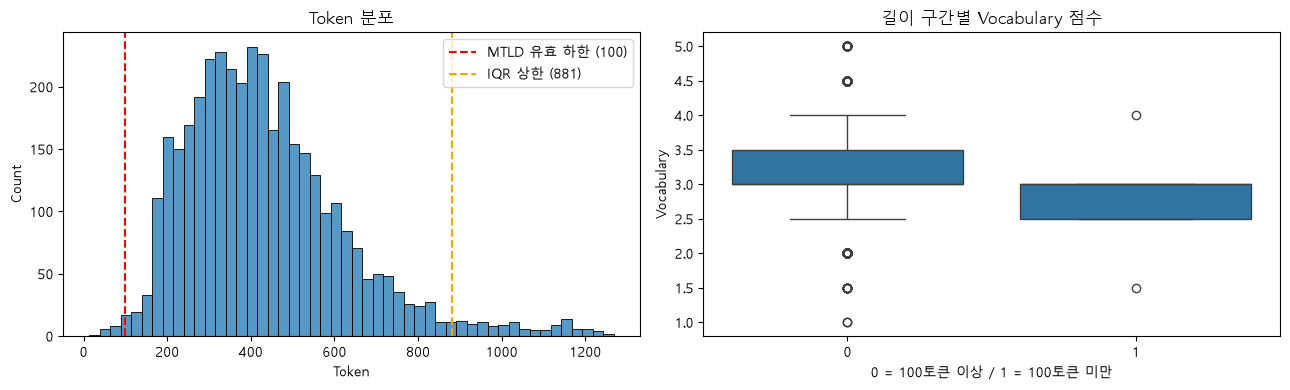

In [76]:
# ── [2-2] 길이 이상치 플래그 생성 (제거하지 않음) ──────────
#
# [0-7]에서 확인했듯 텍스트 길이는 점수와 연관됩니다.
# 따라서 '짧다'는 사실 자체가 예측에 사용 가능한 정보입니다.
#
# 제거하면 정보가 소실되지만, 이진 변수로 인코딩하면 정보로 전환됩니다.
# 같은 관측을 '제외 대상'으로 볼지 '설명 변수'로 볼지는 분석 목적이 결정하며,
# 예측 과제에서는 후자가 적절합니다.
#
# 이런 처리를 이상치의 피처화(feature engineering)라고 합니다.

q1, q3 = df[BASE_TOKEN].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr

print(f'IQR 기준 정상 범위: {lo:.0f} ~ {hi:.0f} 토큰')
print(f'  하한 미만: {(df[BASE_TOKEN] < lo).sum()}건')
print(f'  상한 초과: {(df[BASE_TOKEN] > hi).sum()}건')

# 제거 대신 플래그 컬럼을 생성합니다. 이후 모델의 입력 변수가 됩니다.
df['flag_very_short'] = (df[BASE_TOKEN] < 100).astype(int)   # MTLD 무효 구간
df['flag_len_outlier'] = ((df[BASE_TOKEN] < lo) | (df[BASE_TOKEN] > hi)).astype(int)

print('\n생성된 플래그')
print(f'  flag_very_short  (100토큰 미만): {df["flag_very_short"].sum()}건')
print(f'  flag_len_outlier (IQR 이탈)    : {df["flag_len_outlier"].sum()}건')

# 수치만으로는 판단이 어려우므로 분포와 점수 관계를 함께 시각화합니다.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df[BASE_TOKEN], bins=50, ax=axes[0])
axes[0].axvline(100, color='red', ls='--', label='MTLD 유효 하한 (100)')
axes[0].axvline(hi, color='orange', ls='--', label=f'IQR 상한 ({hi:.0f})')
axes[0].set_title('Token 분포')
axes[0].legend()

sns.boxplot(x=df['flag_very_short'], y=df['Vocabulary'], ax=axes[1])
axes[1].set_title('길이 구간별 Vocabulary 점수')
axes[1].set_xlabel('0 = 100토큰 이상 / 1 = 100토큰 미만')
plt.tight_layout()
plt.show()

In [77]:
# ── [2-3] MTLD 유효 구간 판정 → 무효값 결측 전환 ────────────
#
# MTLD는 TTR이 임계값 아래로 떨어지는 지점까지를 factor로 세고
# 그 factor들의 평균 길이를 산출하는 지표입니다.
#
# 텍스트가 100토큰에 미치지 못하면 factor가 완성되지 않아
# 산출된 값이 어휘 다양성을 반영한다고 볼 수 없습니다.
# 값이 극단적인 것이 아니라 정의되지 않은 상태입니다.
#
# 이 판정으로 두 가지를 동시에 얻습니다.
#   ① 어휘 다양성 지표가 신뢰 가능한 값만 갖게 됩니다.
#   ② 결측치가 0인 데이터에 결측 처리 절차를 적용할 근거가 생깁니다.
#
# 임계값 100은 데이터 분포가 아니라 지표의 정의에서 도출된 값이므로
# train/test 분할 전에 전체 데이터로 계산해도 누수가 발생하지 않습니다.

MTLD_MIN_TOKEN = 100

invalid_mtld = df[BASE_TOKEN] < MTLD_MIN_TOKEN

print(f'MTLD 유효성 판정 (임계값: {MTLD_MIN_TOKEN} 토큰)')
print(f'  무효 구간: {invalid_mtld.sum()}건 ({invalid_mtld.sum() / len(df) * 100:.2f}%)')

if invalid_mtld.sum() > 0:
    print('\n무효 구간 MTLD 분포:')
    print(df.loc[invalid_mtld, 'MTLD'].describe().round(2).to_string())
    print('\n유효 구간 MTLD 분포:')
    print(df.loc[~invalid_mtld, 'MTLD'].describe().round(2).to_string())

# 원본 컬럼은 보존하고 유효성을 반영한 새 컬럼을 생성합니다.
# 원본을 덮어쓰면 판정 이전 값을 확인할 수 없어 검증이 불가능해집니다.
df['MTLD_valid'] = df['MTLD'].where(~invalid_mtld, np.nan)

# 이 단계는 행을 제거하지 않고 값만 결측으로 전환합니다.
# 따라서 처리 전/후 행 수를 동일하게 기록해야 로그가 사실과 일치합니다.
# (앞서 '처리 후'에 무효 건수를 뺀 값을 넣어 행이 줄어든 것처럼 기록되던 오류를 수정)
log_step('STEP 2', 'MTLD 무효값 결측 전환',
         len(df), len(df),
         f'{MTLD_MIN_TOKEN}토큰 미만 {int(invalid_mtld.sum())}건 무효 판정 '
         f'(행 유지, 값만 결측 전환)')

print(f'\nMTLD_valid 생성 — 결측 {df["MTLD_valid"].isna().sum()}건')

MTLD 유효성 판정 (임계값: 100 토큰)
  무효 구간: 21건 (0.56%)

무효 구간 MTLD 분포:
count    21.00
mean     42.76
std      12.43
min      12.25
25%      35.17
50%      42.98
75%      53.56
max      61.18

유효 구간 MTLD 분포:
count    3726.00
mean       45.82
std        10.98
min        19.45
25%        38.04
50%        44.66
75%        51.95
max       103.14

MTLD_valid 생성 — 결측 21건


---

# STEP 3. 결측치 처리

## 목적
STEP 2에서 무효 판정된 값을 어떻게 다룰지 결정합니다.

## 원본에 결측이 없는데 이 단계가 존재하는 이유

원본 데이터의 결측치는 0개였습니다.
STEP 2에서 **값은 존재하지만 신뢰할 수 없는 값**을 식별해 결측으로 전환했습니다.

이는 데이터 품질 점검에서 중요한 관점입니다.

> **결측이 없다는 것이 데이터가 깨끗하다는 뜻은 아닙니다.**
> 오히려 결측이어야 할 자리에 값이 채워져 있는 쪽이 탐지하기 어렵고 위험합니다.

## 결측 처리 방법 3종과 선택

| 방법 | 적용 조건 | 이 데이터 |
|---|---|---|
| 행 삭제 | 결측이 소수이고 무작위일 때 | ❌ 짧은 글의 점수 정보가 소실 |
| 대치(imputation) | 결측이 무작위(MAR/MCAR)일 때 | ⚠️ 조건부 |
| 결측 자체를 변수화 | 결측이 무작위가 아닐 때 | ✅ **채택** |

## 채택 근거: MNAR

이 결측은 무작위로 발생하지 않았습니다. **텍스트가 짧다는 특정 조건에서만** 발생했고,
그 조건은 종속변수(점수)와 연관되어 있습니다.

이런 결측 패턴을 **MNAR(Missing Not At Random)** 이라고 합니다.
결측 발생 원인 자체가 예측 대상과 관련된 경우입니다.

MNAR 상황에서 평균 대치를 적용하면, **"짧은 텍스트인데 평균 수준의 어휘 다양성을 가진 관측"**
이라는 실재하지 않는 데이터를 생성하게 됩니다.

따라서 다음과 같이 처리합니다.

1. 결측 발생 여부를 별도 변수로 보존 — `flag_very_short`가 이미 그 역할
2. 값은 평균이 아닌 **경계값**으로 대치 — 관측 가능한 범위 내의 보수적 값

## 기대 효과
모델이 "이 값은 대치된 값"이라는 정보까지 함께 학습할 수 있습니다.

In [78]:
# ── [3-1] 결측 현황 및 발생 패턴 진단 ──────────────────────
#
# 결측치를 처리하기 전에 반드시 확인해야 할 것은 발생 원인입니다.
# 원인에 따라 적절한 처리 방법이 완전히 달라지기 때문입니다.
#
#   - 무작위로 발생 (MCAR/MAR) → 평균·중앙값 대치가 정당화됨
#   - 특정 조건에서만 발생 (MNAR) → 결측 여부 자체를 변수로 보존해야 함
#
# 아래 출력은 결측 집단과 비결측 집단의 종속변수 분포를 비교합니다.
# 두 집단의 평균이 다르다면 결측이 무작위가 아니라는 증거입니다.

print('결측 현황')
na = df.isna().sum()
na = na[na > 0]
print('  결측 없음' if len(na) == 0 else na.to_string())

if df['MTLD_valid'].isna().sum() > 0:
    miss = df['MTLD_valid'].isna()
    print('\n결측 집단 vs 비결측 집단 비교')
    print(f'  Vocabulary 평균 — 결측 {df.loc[miss, "Vocabulary"].mean():.3f} / '
          f'비결측 {df.loc[~miss, "Vocabulary"].mean():.3f}')
    print(f'  Token 평균      — 결측 {df.loc[miss, BASE_TOKEN].mean():.1f} / '
          f'비결측 {df.loc[~miss, BASE_TOKEN].mean():.1f}')
    print('\n두 집단의 종속변수 평균이 다르면 MNAR로 판정합니다.')
    print('이 경우 평균 대치는 부적절하며, 결측 여부를 변수로 보존해야 합니다.')

결측 현황
MTLD_valid    21

결측 집단 vs 비결측 집단 비교
  Vocabulary 평균 — 결측 2.810 / 비결측 3.231
  Token 평균      — 결측 72.3 / 비결측 436.7

두 집단의 종속변수 평균이 다르면 MNAR로 판정합니다.
이 경우 평균 대치는 부적절하며, 결측 여부를 변수로 보존해야 합니다.


In [79]:
# ── [3-2] 대치 — 평균이 아닌 경계값 사용 ───────────────────
#
# 측정 범위 하한이 5kg인 저울에 3kg 물체를 올리면 눈금은 0을 가리킵니다.
# 이때 알 수 있는 것은 "0kg이다"가 아니라 "5kg보다 가볍다"입니다.
#
# 짧은 텍스트의 MTLD도 동일합니다.
# 측정에 실패했다는 뜻이지, 어휘 다양성이 평균 수준이라는 뜻이 아닙니다.
#
# 따라서 전체 평균(관측되지 않은 값을 추정하는 것)이 아니라
# 유효 구간의 최솟값(관측 범위 내에서 보수적으로 가정 가능한 값)으로 대치합니다.
#
# flag_very_short 컬럼이 함께 존재하므로, 모델은 이 값이 대치된 것임을
# 별도 변수를 통해 인지할 수 있습니다. 정보를 숨기지 않는 방식입니다.

if df['MTLD_valid'].isna().sum() > 0:
    fill_value = df['MTLD_valid'].min()
    mean_value = df['MTLD_valid'].mean()

    print('대치값 후보 비교')
    print(f'  유효 구간 최솟값: {fill_value:.2f}  ← 채택')
    print(f'  유효 구간 평균값: {mean_value:.2f}  ← 미채택 (MNAR에 부적합)')

    df['MTLD_valid'] = df['MTLD_valid'].fillna(fill_value)

    log_step('STEP 3', 'MTLD 결측 대치', 0, 0,
             f'유효구간 최솟값({fill_value:.2f}) 보수적 대치 + flag_very_short 동반')

    print(f'\n대치 완료. 잔여 결측: {df["MTLD_valid"].isna().sum()}건')
else:
    print('무효 구간이 없어 대치 대상이 없습니다.')

print(f'\n전체 결측 최종 확인: {df.isna().sum().sum()}개')

대치값 후보 비교
  유효 구간 최솟값: 19.45  ← 채택
  유효 구간 평균값: 45.82  ← 미채택 (MNAR에 부적합)

대치 완료. 잔여 결측: 0건

전체 결측 최종 확인: 0개


---

# STEP 4. 파생 변수 생성

## 목적
에세이 원문에서 어휘 능력을 반영하는 정형 지표를 추출합니다.

## 현재 보유 지표의 공백

제2언어 작문 연구에는 **CAF**라는 표준 분석 틀이 있습니다.
Complexity(복잡성) · Accuracy(정확성) · Fluency(유창성) 세 축입니다.

이 중 어휘 점수와 직결되는 **Lexical Complexity**는 다시 세 하위 축으로 나뉩니다.

```
Lexical Complexity
├─ ① Lexical Diversity      어휘 다양성 — 서로 다른 단어를 얼마나 쓰는가
├─ ② Lexical Sophistication 어휘 수준   — 저빈도·고난도 어휘를 얼마나 쓰는가
└─ ③ Lexical Density        어휘 밀도   — 내용어 비중이 얼마나 높은가
```

**현재 데이터에는 ①만 존재합니다** (TTR, MTLD, Type, Token).
②와 ③은 완전히 비어 있습니다.

그런데 채점 루브릭 관점에서 보면, 어휘 점수는 "얼마나 다양한가"보다
**"얼마나 수준 높은 어휘를 적절히 사용하는가"** 에 더 가깝습니다.

동일한 명제를 두 방식으로 표현해 보면 차이가 드러납니다.

> A: The problem is very big and it makes people **sad**.
> B: The issue is **substantial** and it **generates considerable distress**.

토큰 수도 비슷하고 다양성 지표도 비슷하지만 어휘 점수는 크게 갈립니다.
그 차이를 만드는 것이 ② Sophistication이며, 현재 이 축이 측정되지 않고 있습니다.

## 생성할 변수군

| 군 | 내용 | 근거 |
|---|---|---|
| **A. 다양성 보정** | Guiraud, Herdan C | 기존 TTR이 길이에 교란되어 있음 |
| **B. 수준 (최우선)** | 빈도 밴드, 어절 길이, 음절, 학술 접미사 | **미측정 축** |
| **C. 밀도** | 내용어 비율, 기능어 비율 | **미측정 축** |
| **D. 정확성** | 사전 미등재율, 반복률, hapax | 오류 주석의 대리지표 |
| **E. 구문** | 평균 문장 길이, 길이 변동성 | 기존 컬럼 조합으로 계산 가능 |
| **F. 과제 상대화** | 프롬프트 기준 표준화 | 주제 편중 대응 |

# 파생변수 정의서 및 설계 검증

`02_preprocessing.ipynb`에서 생성한 파생변수 28종의 정의, 이론적 근거, 실측 성능을 정리한 문서입니다.

| 항목 | 값 |
|---|---|
| 입력 데이터 | `ELLIPSE_Final_github_train.csv` (3,911행 × 26열) |
| 출력 데이터 | `processed_features.csv` (**3,747행 × 41열**) |
| 행 손실률 | 4.19% (164행 — 무효 산출물 제거) |
| 생성 파생변수 | **28개** (A~G 7개 변수군) |
| 종속변수 | `Vocabulary` (1.0~5.0, 0.5 단위 / 평균 3.16, 표준편차 0.579) |

---

## 표 읽는 법

| 열 | 의미 |
|---|---|
| **r(Vocab)** | 종속변수와의 피어슨 상관. 절댓값이 클수록 단변량 예측력이 높음 |
| **r(Token)** | 텍스트 길이와의 상관. **절댓값이 작을수록 길이 교란에서 자유로움** |
| **판정** | 설계 의도가 실측에서 확인되었는지 |

두 열을 함께 봐야 합니다. r(Vocab)이 높아도 r(Token)이 함께 높으면
그 변수는 어휘력이 아니라 **길이를 재고 있을 가능성**이 있습니다.

판정 기준:

- ✅ **성공** — |r(Vocab)| ≥ 0.20 이고 설계 의도와 부호 일치
- ⚠️ **부분** — |r(Vocab)| 0.10 ~ 0.20, 또는 길이 교란이 큼
- ❌ **실패** — |r(Vocab)| < 0.10
- 🔄 **재해석** — 신호는 있으나 설계 의도와 다른 것을 측정하고 있음

---

## A. 어휘 다양성 (보정) — 4개

원본 `TTR`이 길이에 교란되는 문제를 보정하기 위한 변수군입니다.

| 변수 | 계산식 | 설계 의도 | r(Vocab) | r(Token) | 판정 |
|---|---|---|---:|---:|:---:|
| `ttr_ratio` | `TTR / 100` | 원본 TTR의 스케일 통일 (대조군) | **-0.014** | **-0.652** | ❌ |
| `guiraud` | `Type / √Token` | 분모에 √ 적용해 길이 교란 완화 | **+0.394** | +0.376 | ✅ |
| `herdan_c` | `log(Type) / log(Token)` | 로그 변환으로 길이 교란 완화 | +0.122 | -0.420 | ⚠️ |
| `MTLD_valid` | 원본 MTLD, 100토큰 미만은 무효 처리 후 보수적 대치 | 길이 독립적 어휘 다양성 | **+0.363** | **+0.086** | ✅ |

### 이 변수군의 결과가 갖는 의미

**원본 TTR은 어휘 점수를 전혀 예측하지 못합니다 (r = -0.014).**
그러나 길이와는 -0.652로 강하게 연동되어 있습니다.

TTR이 무용해서가 아니라, **어휘 신호가 길이 교란에 상쇄되어 소거된 상태**입니다.
같은 `Type`과 `Token`을 재료로 쓰되 분모 증가 속도만 완만하게 바꾼 `guiraud`가
r = +0.394로 전체 변수 중 최상위에 올라온 것이 그 증거입니다.

> **입력 정보량은 동일한데 조합 방식만 바꿔서 무상관을 최상위 예측변수로 전환했습니다.**
> 이것이 피처 엔지니어링의 효과를 보여주는 이 프로젝트의 대표 사례입니다.

`MTLD_valid`는 예측력(0.363)과 길이 독립성(0.086)을 동시에 만족하는 유일한 변수로,
**길이로 설명되지 않는 순수 어휘 다양성 신호**를 담고 있습니다.
원본 `MTLD`(0.360, 0.065) 대비 예측력이 소폭 개선되어 STEP 2~3의 무효값 처리가 유효했음이 확인됩니다.

`herdan_c`는 로그 변환의 보정 강도가 과했습니다. 길이 상관이 -0.420으로 남았고
예측력도 0.122에 그쳐 `guiraud`에 밀립니다.

---

## B. 어휘 수준 (Lexical Sophistication) — 7개

CAF 분석틀에서 원본 데이터에 없던 축입니다. 설계 시 **최우선 변수군**으로 지정했습니다.

| 변수 | 계산식 | 설계 의도 | r(Vocab) | r(Token) | 판정 |
|---|---|---|---:|---:|:---:|
| `mean_word_length` | 토큰 평균 문자 수 | 저빈도어일수록 길다 | **+0.240** | -0.079 | ✅ |
| `mean_syllables` | 토큰 평균 음절 수 (모음군 기반 추정) | 저빈도어일수록 음절이 많다 | **+0.237** | -0.050 | ✅ |
| `long_word_ratio` | 7자 이상 토큰 비율 | 위와 동일 방향 | **+0.215** | -0.071 | ✅ |
| `k2_ratio` | 빈도 1,001~2,000위 토큰 비율 | 중간 난이도 구간 | +0.131 | -0.069 | ⚠️ |
| `k1_ratio` | 빈도 상위 1,000위 토큰 비율 | 높을수록 어휘 수준 낮음 | -0.114 | +0.119 | ⚠️ |
| `academic_suffix_ratio` | 학술 접미사(-tion, -ity 등) 보유 토큰 비율 | 학술 어휘의 형태적 표지 | +0.103 | -0.060 | ⚠️ |
| `beyond_2k_ratio` | 빈도 2,000위 밖 토큰 비율 | **주력 지표로 설계** | **+0.055** | -0.100 | ❌ |

### `beyond_2k_ratio`가 실패한 원인 — 두 신호의 상쇄

설계 문서에서 주력 지표로 지정한 변수가 사실상 무상관으로 나왔습니다.
원인은 이 변수가 **성격이 정반대인 두 종류의 토큰을 함께 세고 있기 때문**입니다.

```
"빈도 2,000위 밖 토큰"
├─ 고급 어휘        substantial, considerable  → 점수를 올리는 신호 (+)
└─ 철자 오류·비단어  enviroment, alot, becuase  → 점수를 내리는 신호 (−)
```

`beyond_2k_ratio`와 `oov_ratio`(사전 미등재율)의 상관은 **+0.489**입니다.
2,000위 밖 토큰의 상당 부분이 철자 오류라는 뜻이며,
두 신호가 하나의 변수 안에서 서로 상쇄되어 r이 0에 수렴했습니다.

**검증**: 오류 성분을 제거한 잔차를 계산하면 상관이 회복됩니다.

| 변수 | r(Vocab) |
|---|---:|
| `beyond_2k_ratio` (원본) | +0.055 |
| `beyond_2k_ratio − oov_ratio` (오류 성분 제거) | **+0.258** |

**약 4.7배 상승**했습니다. 지표가 잘못된 것이 아니라 **분해되지 않은 상태**였던 것입니다.

> **STEP 6 조치 제안**: `clean_beyond_2k = beyond_2k_ratio − oov_ratio`를 신규 파생변수로 추가.
> 파생변수에서 다시 파생변수를 만드는, 결과 기반 2차 피처 엔지니어링에 해당합니다.

### B군 종합

빈도 밴드 계열(`k1`, `k2`, `beyond_2k`)은 전부 부진한 반면,
형태 기반 계열(`mean_word_length`, `mean_syllables`, `long_word_ratio`)은 전부 성공했습니다.

같은 "어휘 수준"을 재는데 결과가 갈린 이유는 **오류 내성**입니다.
철자가 틀려도 단어의 길이와 음절 수는 대체로 보존되지만,
빈도 밴드 조회는 철자가 하나만 틀려도 즉시 "미등재"로 분류됩니다.

세 변수는 r(Token)이 모두 -0.05~-0.08로 길이와 사실상 독립이라는 점에서도 가치가 높습니다.

---

## C. 어휘 밀도 (Lexical Density) — 3개

| 변수 | 계산식 | 설계 의도 | r(Vocab) | r(Token) | 판정 |
|---|---|---|---:|---:|:---:|
| `lexical_density` | 내용어 수 / 전체 토큰 수 | 분량 대비 정보 밀도 | +0.092 | -0.131 | ❌ |
| `function_word_ratio` | 기능어 수 / 전체 토큰 수 | 위의 여집합 | -0.092 | +0.131 | ❌ |
| `content_ttr` | 내용어만의 Type/Token | 순수 어휘 선택 능력 | +0.051 | -0.405 | ❌ |

**변수군 전체가 실패했습니다.** 어휘 밀도는 이 데이터의 어휘 점수를 설명하지 못합니다.

가능한 해석은, 모든 응답이 동일한 과제 유형(독립형 논술)이라
텍스트 장르가 통일되어 있고 내용어/기능어 비율의 개체 간 변동이 작았다는 것입니다.
어휘 밀도는 원래 장르 간 비교(구어 vs 문어, 학술 vs 일상)에서 변별력을 갖는 지표입니다.

`lexical_density`와 `function_word_ratio`는 합이 정확히 1인 **완전 여집합**이므로
어차피 한쪽만 유지해야 합니다.
아래 R² 사전 점검에서도 두 변수를 함께 투입하면 설계행렬이 특이(singular)해지므로
`function_word_ratio`를 제외하고 계산했습니다. 두 경우의 R²는 0.3402로 동일합니다.

---

## D. 정확성 대리지표 (Accuracy Proxy) — 3개

철자 오류를 **교정하지 않고 신호로 사용**한다는 판단으로 설계한 변수군입니다.

| 변수 | 계산식 | 설계 의도 | r(Vocab) | r(Token) | 판정 |
|---|---|---|---:|---:|:---:|
| `oov_ratio` | 사전 미등재 토큰 비율 | 철자 오류의 대리값 | **-0.318** | -0.125 | ✅ |
| `hapax_ratio` | 1회 출현 타입 / 전체 타입 | 어휘 창의성 | +0.105 | -0.279 | ⚠️ |
| `repeat_bigram_ratio` | 동일 토큰 연속 출현 비율 | 퇴고 부족 신호 | -0.038 | -0.021 | ❌ |

### `oov_ratio` — 이 프로젝트에서 가장 방어력이 강한 변수

r = **-0.318**로 전체 3위이며, 길이 상관은 -0.125로 낮습니다.
부호도 설계 의도와 정확히 일치합니다 — **오류가 많을수록 어휘 점수가 낮습니다.**

통상적인 NLP 전처리는 오타를 교정합니다.
이 프로젝트는 종속변수가 학습자의 어휘 능력이고 철자 오류는 해당 어휘를
확립하지 못했다는 관측 가능한 증거라는 이유로 교정하지 않았습니다.

**표준 전처리를 따랐다면 r = -0.318짜리 상위 예측변수가 소멸했을 것입니다.**
전처리의 정답이 분석 목적에 종속된다는 것을 보여주는 실증 사례입니다.

`hapax_ratio`는 짧은 텍스트에서 자동 상승하는 구조적 문제(r(Token) = -0.279)가
설계 시 우려한 대로 나타났습니다.
`repeat_bigram_ratio`는 평균 0.0008로 사건 자체가 거의 발생하지 않아 변별력이 없습니다.

---

## E. 구문 지표 — 5개

어휘 발달과 구문 발달이 동반 진행된다는 가정에서 설계했습니다.

| 변수 | 계산식 | 설계 시 예상 부호 | r(Vocab) | r(Token) | 판정 |
|---|---|:---:|---:|---:|:---:|
| `sent_per_para` | 문장 수 / 문단 수 | + | +0.178 | +0.243 | ⚠️ |
| `mean_sent_length` | Token / 문장 수 | **+ (예상)** | **-0.170** | +0.074 | 🔄 |
| `sent_length_std` | 문장별 길이의 표준편차 | **+ (예상)** | **-0.166** | +0.159 | 🔄 |
| `sent_length_max` | 최장 문장의 토큰 수 | + | -0.135 | +0.275 | 🔄 |
| `mean_para_length` | Token / 문단 수 | + | +0.069 | +0.320 | ❌ |

### 부호가 예상과 반대로 나온 이유

`mean_sent_length`, `sent_length_std`, `sent_length_max` 세 변수 모두
설계 시 예상한 부호와 **정반대**로 나왔습니다.
문장이 길수록, 문장 길이의 변주가 클수록 어휘 점수가 **낮습니다.**

원인은 데이터에서 확인됩니다.

| 확인 항목 | 값 |
|---|---|
| `mean_sent_length` 최댓값 | **590.5 토큰** |
| 문장이 1개로 판정된 에세이 | 22편 |
| 해당 22편의 평균 Vocabulary | **2.43** (전체 평균 3.16) |

한 문장이 590 토큰이라는 것은 구문이 복잡한 것이 아니라
**마침표를 찍지 않았다는 뜻**입니다.

제2언어 작문에서 긴 문장은 두 가지 경로로 발생합니다.

1. 종속절을 적절히 사용한 복문 → 숙련도 높음
2. 접속사 남발 및 문장 경계 미확립(run-on sentence) → 숙련도 낮음

이 데이터에서는 **2번이 지배적**입니다.
문장 길이 이상치를 제외해도(60토큰 미만, n=3,509) r = -0.153으로 음의 부호가 유지되므로,
소수 극단값의 문제가 아니라 집단 전체의 경향입니다.

> **결론**: 이 변수들은 부호가 틀린 것이 아니라 **측정 대상이 다릅니다.**
> "구문 복잡도"가 아니라 **"문장 경계 통제 능력"** 을 재고 있습니다.
> 변수명과 해석을 이 방향으로 수정하면 그대로 유효한 예측변수입니다.

---

## F. 과제 상대화 (Task Normalization) — 3개

프롬프트 44종의 기대 분량 차이를 보정하기 위한 변수군입니다.

| 변수 | 계산식 | 설계 의도 | r(Vocab) | r(Token) | 판정 |
|---|---|---|---:|---:|:---:|
| `len_z_in_prompt` | 프롬프트 그룹 내 Token의 z-score | 상대적 길이 | +0.271 | **+0.951** | 🔄 |
| `soph_z_in_prompt` | 프롬프트 그룹 내 `beyond_2k_ratio`의 z-score | 상대적 어휘 수준 | +0.052 | -0.115 | ❌ |
| `prompt_freq` | 해당 프롬프트의 응답 편수 | 그룹 통계 안정성 | -0.046 | +0.106 | ❌ |

### `len_z_in_prompt`의 문제

r(Vocab) = 0.271로 원본 `Token`(0.267)보다 근소하게 높지만,
**`Token`과의 상관이 0.951**입니다. 사실상 같은 변수입니다.

프롬프트별 표준화가 거의 효과를 내지 못했다는 뜻이며,
이는 **프롬프트 간 평균 길이 차이가 애초에 작았기** 때문으로 보입니다.
설계 시 가정한 "주제마다 기대 분량이 다르다"가 이 데이터에서는 성립하지 않았습니다.

`soph_z_in_prompt`는 원재료인 `beyond_2k_ratio` 자체가 실패했으므로
표준화해도 신호가 생기지 않았습니다.

> **STEP 6 조치**: `len_z_in_prompt`와 `Token` 중 하나만 유지.
> 다만 `clean_beyond_2k`를 신규 생성한다면 그것을 재료로 `soph_z`를 다시 계산해볼 가치는 있습니다.

---

## G. 플래그 — 3개

| 변수 | 정의 | 건수 | r(Vocab) | 판정 |
|---|---|---:|---:|:---:|
| `flag_very_short` | 100토큰 미만 (MTLD 무효 구간) | 21건 (0.56%) | -0.054 | ❌ |
| `flag_len_outlier` | Token IQR 이탈 | 123건 (3.28%) | +0.062 | ❌ |
| `n_pii` | 개인정보 마스킹 토큰 출현 횟수 | 총 1,560회 | +0.025 | ❌ |

세 변수 모두 단변량 예측력은 없습니다.
(`n_pii`는 STEP 0의 개인정보 토큰 점검 과정에서 생성되었으나,
노트북 `[4-Z]`의 `DERIVED` 집계에 G군으로 포함되어 있어 본 문서도 동일 기준을 따릅니다.)

다만 `flag_very_short`는 **예측이 아니라 대치 표시가 목적**인 변수입니다.
`MTLD_valid`가 대치된 21건을 모델이 식별할 수 있게 하는 역할이므로,
상관이 낮다는 이유로 제거하면 대치 정보가 함께 소실됩니다.
`MTLD_valid`를 최종 피처로 유지한다면 이 변수도 함께 유지해야 합니다.

---

## 종합 — 예측력 상위 10개

| 순위 | 변수 | 변수군 | r(Vocab) | r(Token) | 비고 |
|---:|---|---|---:|---:|---|
| 1 | `Type` | 원본 | +0.394 | +0.855 | 길이와 거의 동일 — 사용 부적합 |
| 2 | **`guiraud`** | A | **+0.394** | +0.376 | 최상위 파생변수 |
| 3 | **`MTLD_valid`** | A | **+0.363** | **+0.086** | 길이 독립성 최고 |
| 4 | `num_sent` | 원본 | +0.334 | +0.632 | 길이 대리변수 |
| 5 | **`oov_ratio`** | D | **-0.318** | -0.125 | 표준 전처리 역행의 성과 |
| 6 | `len_z_in_prompt` | F | +0.271 | +0.951 | `Token`과 중복 |
| 7 | `Token` | 원본 | +0.267 | 1.000 | 길이 그 자체 |
| 8 | **`mean_word_length`** | B | **+0.240** | -0.079 | 형태 기반, 길이 독립 |
| 9 | **`mean_syllables`** | B | **+0.237** | -0.050 | 위와 동일 구성 개념 |
| 10 | **`long_word_ratio`** | B | **+0.215** | -0.071 | 위와 동일 구성 개념 |

원본 컬럼(`Type`, `num_sent`, `Token`)은 예측력이 있어 보이지만
r(Token)이 0.63~1.00으로 **전부 길이를 재고 있습니다.**
길이 교란에서 자유로우면서 예측력을 갖춘 변수는 전부 이번에 생성한 파생변수입니다.

---

## 설계 가설의 검증 결과

| 설계 시 가설 | 실측 결과 | 판정 |
|---|---|:---:|
| TTR은 길이에 교란되어 있다 | r(Token) = -0.652 | ✅ 확인 |
| √·log 보정으로 교란을 줄일 수 있다 | guiraud 0.376 / herdan_c -0.420 | ✅ 부분 확인 |
| 어휘 수준(B)이 최우선 변수군이다 | 형태 계열은 성공, 빈도 밴드는 실패 | ⚠️ 절반 |
| 철자 오류는 제거가 아니라 신호다 | r = -0.318, 전체 3위 | ✅ 확인 |
| 어휘 밀도가 어휘 점수를 설명한다 | 전 변수 r < 0.10 | ❌ 기각 |
| 어휘 발달과 구문 발달은 동반한다 | 부호 반전 — 다른 것을 측정 중 | 🔄 재해석 |
| 프롬프트별 기대 분량이 다르다 | Token과 r = 0.951 | ❌ 기각 |

**7개 중 3개 확인, 2개 기각, 1개 부분, 1개 재해석.**

가설이 전부 맞는 것보다 이 분포가 분석으로서는 바람직합니다.
전부 맞았다면 검증이 아니라 확인에 그쳤을 것이며,
기각과 재해석이 나온 지점에서 데이터에 대한 새로운 정보가 산출되었습니다.

---

## 참고: 선형회귀 R² 사전 점검

**주의**: 아래는 train/test 분할 전 전체 데이터 기준이므로 낙관적으로 편향된 값입니다.
확정 성능이 아니라 방향 확인용입니다.

| 입력 변수 | R² |
|---|---:|
| `Token` 단독 (길이 베이스라인) | **0.071** |
| 핵심 4개 (`guiraud`, `MTLD_valid`, `oov_ratio`, `mean_word_length`) | **0.280** |
| 파생변수 28개 전체 | **0.340** |

### 해석

**길이만으로 설명되는 몫은 7.1%에 불과합니다.**
자동 채점에서 흔히 지적되는 "길게 쓰면 점수가 오른다"는 우려가
이 데이터의 어휘 점수에서는 크게 문제되지 않습니다.

핵심 4개만으로 R² 0.280에 도달하며, 이는 **길이 베이스라인 대비 4배**입니다.
차이인 0.209가 파생변수 설계의 순수 기여분입니다.

28개 전체 투입 시 0.340이지만, 4개 → 28개로 24개를 추가해 얻은 증가폭은 0.060에 그칩니다.
**변수 대비 효율이 급격히 떨어지는 구간**이며, STEP 6의 변수 선택이 필요한 이유입니다.

측정된 R² 0.34는 프로젝트 설계 단계에서 선언한 목표 구간(0.30~0.45)에 들어옵니다.
선행 연구의 다차원 모델이 보고한 Vocabulary 차원 Pearson 0.599(R² 환산 약 0.36)와도
근접한 수준입니다.

---

## STEP 6 조치 목록

### 신규 생성

| 변수 | 계산식 | 근거 |
|---|---|---|
| `clean_beyond_2k` | `beyond_2k_ratio − oov_ratio` | r 0.055 → 0.258 (4.7배) |

### 제거 대상 (구성 개념 중복 — 각 그룹에서 1개만 유지)

| 그룹 | 후보 | 권장 유지 | 사유 |
|---|---|---|---|
| 다양성 | `ttr_ratio`, `guiraud`, `herdan_c` | **`guiraud`** | 예측력 최고, 교란 최소 |
| 여집합 쌍 | `lexical_density`, `function_word_ratio` | 둘 다 제거 검토 | 합이 1, 예측력 없음 |
| 여집합 쌍 | `k1_ratio`, `beyond_2k_ratio` | `clean_beyond_2k`로 대체 | 합이 거의 1 |
| 형태 계열 | `mean_word_length`, `mean_syllables`, `long_word_ratio` | **VIF로 판정** | 동일 구성 개념, 셋 다 성공 |
| 길이 계열 | `Token`, `len_z_in_prompt`, `num_words3` | **`Token`** | r = 0.95~0.999 |

### 예측력 없음 — 제거 후보

`repeat_bigram_ratio`, `prompt_freq`, `soph_z_in_prompt`, `n_pii`, `content_ttr`, `mean_para_length`

### 유지 (예측 외 목적)

`flag_very_short` — `MTLD_valid`의 대치 여부 표시. 단독 예측력이 아닌 정보 보존이 목적.

### 변수 재명명 제안

| 현재 | 제안 | 사유 |
|---|---|---|
| `mean_sent_length` | `sent_boundary_control` 계열로 재해석 | 구문 복잡도가 아니라 문장 경계 통제를 측정 |

---

## 최종 판정

파생변수 설계는 **성공했습니다.**

근거는 R² 수치가 아니라 상위 예측변수의 구성입니다.
길이 교란에서 자유로우면서 예측력을 갖춘 변수(`MTLD_valid`, `oov_ratio`,
`mean_word_length`, `mean_syllables`, `long_word_ratio`)가 **전부 이번에 생성한 것**이며,
원본 컬럼 중 예측력이 높아 보이는 것들은 실제로는 길이를 재고 있었습니다.

동시에 실패한 변수군(C 밀도, F 상대화)과 재해석이 필요한 변수군(E 구문)이
명확히 드러난 것도 이 검증의 성과입니다.
특히 `beyond_2k_ratio`의 실패 원인을 규명해 `clean_beyond_2k`를 도출한 과정은
**1차 결과를 근거로 한 2차 피처 엔지니어링**의 사례로 결과 해석에 활용 가능합니다.

## 기대 효과

STEP 4 이전까지 보유한 정보는 텍스트의 **규모**에 관한 것이었습니다(단어·문장·문단 수).
STEP 4 이후에는 텍스트의 **질적 특성**을 정형 변수로 갖게 됩니다.

이 프로젝트의 차별점이 여기에 있습니다. BERT 계열 딥러닝 모델은 예측 성능은 높지만
어떤 언어적 특성이 그 점수를 만들었는지 설명하지 못합니다.
반대로 해석 가능한 지표를 직접 설계하면, 성능이 다소 낮더라도
**"어떤 언어 특성이 어휘 점수를 설명하는가"** 라는 질문에 답할 수 있습니다.

In [80]:
# ── [4-0] 토큰화 규칙 정의 ─────────────────────────────────
#
# 단어를 세기 전에 "무엇을 하나의 단어로 볼 것인가"를 확정해야 합니다.
# 이 규칙이 이후 모든 지표에 공통 적용되므로, 규칙이 섞이면 지표 간 비교가 불가능해집니다.
#
# 여기서는 알파벳 연속과 내부 아포스트로피를 하나의 토큰으로 정의합니다.
# (don't → 1토큰)

# 기능어(function word): 문법적 역할을 담당하지만 어휘적 의미가 희박한 단어.
# the, is, of 등이 해당하며, 개수가 한정된 닫힌 집합(closed class)입니다.
# 반대 개념인 내용어(content word)는 dog, run, beautiful처럼 의미를 담은 단어입니다.
#
# 이 구분이 필요한 이유는 어휘 능력이 내용어 선택에서 드러나기 때문입니다.
# the를 많이 쓴다고 어휘력이 높아지지는 않습니다.
FUNCTION_WORDS = set("""
a an the this that these those my your his her its our their whose
i me you he him she it we us they them one ones oneself myself yourself
himself herself itself ourselves yourselves themselves who whom which what
be am is are was were been being have has had having do does did doing
will would shall should can could may might must ought need dare
and or but nor for yet so because although though while whereas since
unless until if whether than as when where why how
in on at by with about against between into through during before after
above below to from up down out off over under again further then once
here there all any both each few more most other some such no not only
own same too very s t just don now
of into onto upon within without across along around behind beyond
""".split())

TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")


def tokenize(text):
    """소문자 토큰 리스트를 반환합니다. [0-5]에서 통일한 개인정보 토큰은 제외합니다."""
    text = str(text).replace('__PII__', ' ')
    return TOKEN_RE.findall(text.lower())


df['_tokens'] = df['full_text'].apply(tokenize)
df['_ntok'] = df['_tokens'].apply(len)

# 우리 토큰화 규칙이 원본 Token 컬럼과 얼마나 일치하는지 확인합니다.
# 상관이 0.99 이상이면 두 규칙이 사실상 동일하다고 볼 수 있습니다.
print('토큰화 완료')
print(f'  평균 토큰 수: {df["_ntok"].mean():.1f}')
print(f'  원본 Token 컬럼과의 상관: {df["_ntok"].corr(df[BASE_TOKEN]):.4f}')

토큰화 완료
  평균 토큰 수: 428.5
  원본 Token 컬럼과의 상관: 0.9995


In [81]:
# ── [4-0b] 어휘 빈도 밴드 구축 ─────────────────────────────
#
# 어휘 수준을 측정하려면 단어의 난이도를 판정할 기준이 필요합니다.
# 영어 교육 연구에서는 이를 빈도 밴드(frequency band)로 조작화합니다.
#
#   K1 밴드: 사용 빈도 상위 1,000개 단어
#   K2 밴드: 1,001~2,000위 단어
#   그 밖   : 2,000위 밖 — 저빈도 어휘로 간주
#
# 이 발상은 Laufer & Nation의 Lexical Frequency Profile에서 온 것으로,
# 학습자가 산출한 텍스트를 빈도 구간별로 분해해 어휘 수준을 프로파일링하는 방식입니다.
#
# wordfreq 패키지가 있으면 실제 영어 사용 빈도를 사용하고,
# 없으면 이 코퍼스 내부 빈도로 대체합니다.
# 후자는 "영어에서 흔한 단어"가 아니라 "이 데이터에서 흔한 단어"이므로
# 설명력이 떨어집니다. 가능하면 설치를 권합니다: pip install wordfreq

USE_WORDFREQ = False
try:
    from wordfreq import top_n_list
    K1 = set(top_n_list('en', 1000))
    K2 = set(top_n_list('en', 2000)) - K1
    USE_WORDFREQ = True
    print('빈도 기준: wordfreq (실제 영어 사용 빈도)')
except ImportError:
    print('wordfreq 미설치 — 코퍼스 내부 빈도로 대체합니다.')
    print('설치 권장: pip install wordfreq')
    all_counter = Counter()
    for toks in df['_tokens']:
        all_counter.update(toks)
    ranked = [w for w, _ in all_counter.most_common()]
    K1 = set(ranked[:1000])
    K2 = set(ranked[1000:2000])

print(f'  K1 밴드: {len(K1)}개 / K2 밴드: {len(K2)}개')

빈도 기준: wordfreq (실제 영어 사용 빈도)
  K1 밴드: 1000개 / K2 밴드: 1000개


### A. 어휘 다양성 보정

**TTR에는 구조적 결함이 있습니다: 텍스트 길이가 증가하면 값이 체계적으로 하락합니다.**

원인은 단순합니다. 텍스트가 길어질수록 이미 사용한 단어를 재사용할 확률이 높아집니다.
기능어는 특히 반복이 불가피합니다. 따라서 **긴 텍스트는 어휘력과 무관하게 TTR이 낮게 측정**됩니다.

이 상태로 모델에 투입하면 TTR이 사실상 텍스트 길이의 역함수처럼 작동해,
길이 관련 변수와 심한 다중공선성을 형성합니다.

| 지표 | 계산식 | 보정 원리 |
|---|---|---|
| Guiraud Index (Root TTR) | Type ÷ √Token | 분모에 제곱근을 적용해 길이 영향을 완화 |
| Herdan's C (Log TTR) | log(Type) ÷ log(Token) | 로그 변환으로 길이 영향을 완화 |

두 지표 모두 분모가 완만하게 증가하도록 만들어 길이 교란을 줄이는 방식입니다.

아래 셀은 보정 전후로 **각 지표와 Token의 상관이 실제로 감소했는지** 검증합니다.
보정을 적용했다는 사실이 아니라 효과가 있었다는 근거가 필요하기 때문입니다.

In [82]:
# ── [4-A] 어휘 다양성 지표 보정 ────────────────────────────
#
# TTR = Type / Token 입니다.
#   100토큰 중 60타입 → TTR 0.60
#   1000토큰 중 400타입 → TTR 0.40
#
# 후자의 어휘력이 낮은 것이 아니라, 길이가 길어 반복이 늘어난 결과입니다.
# 이처럼 지표가 측정 대상 외의 변수(길이)에 체계적으로 영향받는 것을
# 교란(confounding)이라고 합니다.
#
# 분모에 제곱근이나 로그를 적용하면 길이 증가에 따른 분모 증가 속도가 완만해져
# 교란이 완화됩니다.

eps = 1e-9

# Guiraud Index (Root TTR)
df['guiraud'] = df['Type'] / np.sqrt(df[BASE_TOKEN] + eps)

# Herdan's C (Log TTR)
df['herdan_c'] = np.log(df['Type'] + eps) / np.log(df[BASE_TOKEN] + eps)

# 원본 TTR은 0~100 스케일이므로 다른 비율 지표와 맞춰 0~1로 변환합니다.
df['ttr_ratio'] = df['TTR'] / 100.0

# 보정 효과 검증: 각 지표와 Token의 상관이 낮을수록 길이 교란에서 자유롭습니다.
check = df[['ttr_ratio', 'guiraud', 'herdan_c', 'MTLD_valid', BASE_TOKEN]].corr()
print('다양성 지표 × 텍스트 길이(Token) 상관')
print('  절댓값이 0에 가까울수록 길이 교란이 적음')
for c in ['ttr_ratio', 'guiraud', 'herdan_c', 'MTLD_valid']:
    r = check.loc[c, BASE_TOKEN]
    verdict = '양호' if abs(r) < 0.4 else ('주의' if abs(r) < 0.7 else '교란 심함')
    print(f'  {c:12s}: {r:+.3f}  {verdict}')

다양성 지표 × 텍스트 길이(Token) 상관
  절댓값이 0에 가까울수록 길이 교란이 적음
  ttr_ratio   : -0.652  주의
  guiraud     : +0.376  양호
  herdan_c    : -0.420  주의
  MTLD_valid  : +0.086  양호


### B. 어휘 수준 (Lexical Sophistication) — 최우선 변수군

앞서 확인했듯 이 축은 현재 데이터에 전혀 없습니다.
그런데 채점자가 어휘 점수를 산정할 때 실제로 평가하는 것은 대부분 이 축입니다.

#### 생성 지표

| 지표 | 정의 | 방향 |
|---|---|---|
| `k1_ratio` | 최고빈도 1,000단어 비율 | 높을수록 어휘 수준 낮음 |
| `k2_ratio` | 1,001~2,000위 단어 비율 | 중간 구간 |
| `beyond_2k_ratio` | 2,000위 밖 단어 비율 | **주력 지표** — 높을수록 수준 높음 |
| `mean_word_length` | 평균 문자 수 | 저빈도어일수록 길다 |
| `mean_syllables` | 평균 음절 수 | 저빈도어일수록 음절이 많다 |
| `long_word_ratio` | 7자 이상 단어 비율 | 위와 동일 방향 |
| `academic_suffix_ratio` | 학술 접미사 보유 단어 비율 | 학술 어휘의 형태적 표지 |

#### `k1_ratio`가 아니라 `beyond_2k_ratio`를 주력으로 삼는 이유

두 지표는 거의 여집합 관계라 담고 있는 정보량은 비슷합니다.
차이는 **분산**에 있습니다.

- `k1_ratio`는 대부분의 텍스트에서 70~85% 구간에 집중됩니다 → 개체 간 변별력이 낮음
- `beyond_2k_ratio`는 2~20% 구간에 분포합니다 → **상대적 변동폭이 커 변별력이 높음**

동일한 정보라도 분산이 큰 쪽이 회귀에서 유용합니다.
다만 두 변수를 함께 투입하면 합이 거의 1로 고정되어 다중공선성이 발생하므로,
STEP 6에서 한쪽을 제거해야 합니다.

In [83]:
# ── [4-B] 어휘 수준 지표 ───────────────────────────────────
#
# "다양한 단어를 썼다"와 "수준 높은 단어를 썼다"는 서로 다른 구성 개념입니다.
#
#   A: I like dogs. I like cats. I like birds.
#      → 타입 수가 적고 반복이 많음
#   B: I enjoy dogs, adore cats, and cherish birds.
#      → 동일 명제를 저빈도 어휘로 표현
#
# TTR은 B의 다양성이 높다는 것까지는 포착하지만,
# B가 사용한 어휘의 난이도는 전혀 반영하지 못합니다.
# 그 부분을 측정하는 것이 이 셀의 지표들입니다.


def count_syllables(word):
    """
    음절 수 추정. 모음군 하나를 1음절로 계산하고,
    발음되지 않는 어말 e(silent e)를 보정합니다. (make → 1음절)
    사전 없이 쓸 수 있는 표준적인 근사 규칙입니다.
    """
    w = word.lower().strip("'")
    if not w:
        return 0
    n = len(re.findall(r'[aeiouy]+', w))
    if w.endswith('e') and n > 1 and not w.endswith(('le', 'ee', 'ye')):
        n -= 1
    return max(n, 1)


# 학술 어휘에 특징적으로 나타나는 파생 접미사입니다.
# govern → government, active → activity 처럼 추상 명사·형용사를 만드는 형태소로,
# 학술 텍스트에서 출현 빈도가 높습니다.
ACADEMIC_SUFFIXES = ('tion', 'sion', 'ment', 'ity', 'ance', 'ence',
                     'ism', 'ize', 'ise', 'ate', 'ous', 'ive', 'ical', 'able')


def sophistication_features(tokens):
    n = len(tokens)
    if n == 0:
        return pd.Series({'k1_ratio': 0.0, 'k2_ratio': 0.0, 'beyond_2k_ratio': 0.0,
                          'mean_word_length': 0.0, 'mean_syllables': 0.0,
                          'long_word_ratio': 0.0, 'academic_suffix_ratio': 0.0})

    k1 = sum(t in K1 for t in tokens)
    k2 = sum(t in K2 for t in tokens)
    lengths = [len(t) for t in tokens]
    sylls = [count_syllables(t) for t in tokens]

    return pd.Series({
        'k1_ratio': k1 / n,
        'k2_ratio': k2 / n,
        'beyond_2k_ratio': (n - k1 - k2) / n,
        'mean_word_length': float(np.mean(lengths)),
        'mean_syllables': float(np.mean(sylls)),
        'long_word_ratio': sum(l >= 7 for l in lengths) / n,
        'academic_suffix_ratio': sum(t.endswith(ACADEMIC_SUFFIXES) for t in tokens) / n,
    })


soph = df['_tokens'].apply(sophistication_features)
df = pd.concat([df, soph], axis=1)

print('어휘 수준 지표 생성 완료')
print(soph.describe().round(4).to_string())

print('\nVocabulary 점수와의 상관 (절댓값이 클수록 예측 기여도 높음)')
for c in soph.columns:
    r = df[c].corr(df['Vocabulary'])
    print(f'  {c:24s}: {r:+.3f} {corr_bar(r)}')

어휘 수준 지표 생성 완료
        k1_ratio   k2_ratio  beyond_2k_ratio  mean_word_length  mean_syllables  long_word_ratio  academic_suffix_ratio
count  3747.0000  3747.0000        3747.0000         3747.0000       3747.0000        3747.0000              3747.0000
mean      0.8495     0.0602           0.0902            4.2447          1.3616           0.1547                 0.0250
std       0.0459     0.0239           0.0379            0.2753          0.0925           0.0453                 0.0173
min       0.3349     0.0000           0.0033            3.2662          1.0984           0.0191                 0.0000
25%       0.8227     0.0432           0.0652            4.0587          1.2980           0.1231                 0.0123
50%       0.8538     0.0579           0.0852            4.2345          1.3534           0.1515                 0.0218
75%       0.8815     0.0741           0.1099            4.4148          1.4161           0.1827                 0.0336
max       0.9636     0.2549      

### C. 어휘 밀도 (Lexical Density)

텍스트는 두 종류의 단어로 구성됩니다.

- **내용어(content word)**: dog, run, beautiful — 어휘적 의미를 담은 단어
- **기능어(function word)**: the, is, of — 문법적 역할을 담당하는 단어

**어휘 밀도 = 내용어 수 ÷ 전체 토큰 수**

밀도가 높다는 것은 동일 분량에 더 많은 명제적 정보를 담았다는 의미입니다.
밀도가 낮으면 분량 대비 내용이 희박한 텍스트에 가깝습니다.

#### 품사 태거(spaCy)를 사용하지 않은 이유

spaCy로 품사 태깅을 하면 명사·동사·형용사 비율까지 세분할 수 있어 더 정확합니다.
다만 3,900편 처리에 상당한 시간이 소요되어 5일 일정에는 부담입니다.

기능어는 개수가 한정된 닫힌 집합이므로, 목록 기반 판정만으로도
내용어/기능어 구분은 충분히 정확하게 수행됩니다.

> 일정에 여유가 생기면 spaCy로 품사별 비율을 추가하는 것이 다음 확장 순위입니다.
> 다만 우선순위는 B(어휘 수준)가 앞섭니다.

In [84]:
# ── [4-C] 어휘 밀도 지표 ───────────────────────────────────
#
# 동일한 토큰 수라도 내용어 비중은 크게 다를 수 있습니다.
#
#   A: I think that it is a thing that is very good and I like it a lot.
#      → 내용어 4개 (think, thing, good, like), 나머지는 전부 기능어
#   B: Renewable energy reduces carbon emissions and improves public health.
#      → 내용어 8개
#
# 이 차이를 정량화하는 것이 어휘 밀도입니다.
# 텍스트가 길다는 것과 내용이 많다는 것을 분리해 측정할 수 있게 됩니다.

def density_features(tokens):
    n = len(tokens)
    if n == 0:
        return pd.Series({'lexical_density': 0.0, 'content_ttr': 0.0,
                          'function_word_ratio': 0.0})

    content = [t for t in tokens if t not in FUNCTION_WORDS]
    nc = len(content)

    return pd.Series({
        'lexical_density': nc / n,
        # 내용어만으로 계산한 TTR.
        # 기능어가 제외되므로 순수한 어휘 선택 능력에 더 가까운 지표입니다.
        'content_ttr': (len(set(content)) / nc) if nc else 0.0,
        'function_word_ratio': (n - nc) / n,
    })


dens = df['_tokens'].apply(density_features)
df = pd.concat([df, dens], axis=1)

print('어휘 밀도 지표 생성 완료')
print(dens.describe().round(4).to_string())

print('\nVocabulary 점수와의 상관')
for c in dens.columns:
    r = df[c].corr(df['Vocabulary'])
    print(f'  {c:22s}: {r:+.3f} {corr_bar(r)}')

어휘 밀도 지표 생성 완료
       lexical_density  content_ttr  function_word_ratio
count        3747.0000    3747.0000            3747.0000
mean            0.4484       0.5318               0.5516
std             0.0448       0.1065               0.0448
min             0.2941       0.1975               0.2170
25%             0.4188       0.4592               0.5241
50%             0.4476       0.5281               0.5524
75%             0.4759       0.6019               0.5812
max             0.7830       0.8986               0.7059

Vocabulary 점수와의 상관
  lexical_density       : +0.092 ███
  content_ttr           : +0.051 ██
  function_word_ratio   : -0.092 ███


### D. 정확성 대리지표 (Accuracy Proxy)

여기서 일반적인 텍스트 전처리와 정반대의 처리를 합니다.

> **철자 오류는 제거 대상이 아니라 예측 신호입니다.**

통상적인 NLP 전처리에서는 오타를 교정합니다. 그러나 이 프로젝트의 종속변수는
학습자의 **어휘 능력**이고, 철자 오류는 해당 어휘를 확립하지 못했다는 증거입니다.

오타를 교정하면 그 증거를 분석자가 직접 제거하는 것이 됩니다.

#### CLC / NUCLE 오류 주석 체계의 간이 대체

정식 학습자 코퍼스는 오류마다 사람이 태그를 부착합니다.
Cambridge Learner Corpus의 코딩 체계(Nicholls 2003)는 `오류범주 + 품사` 2문자 코드를 쓰고,
NUCLE과 CoNLL shared task는 이를 문법오류교정(GEC)용으로 표준화했습니다.

수작업 태깅은 불가능하지만, **오류 밀도의 근사치**는 계산할 수 있습니다.

| 지표 | 방법 |
|---|---|
| `oov_ratio` | 사전 미등재 토큰 비율 — 철자 오류의 대리값 |
| `repeat_bigram_ratio` | 동일 토큰 연속 출현 비율 |
| `hapax_ratio` | 1회만 출현한 타입의 비율 |

#### `hapax_ratio`의 해석 주의점

1회만 등장한 단어(hapax legomenon)의 비율은 어휘 창의성의 지표로 쓰입니다.
숙련된 필자일수록 동일 어휘 반복을 피하고 새로운 어휘를 계속 도입하기 때문입니다.

다만 이 지표는 **짧은 텍스트에서 자동으로 상승**합니다.
모든 단어가 1회씩만 등장하기 때문입니다.
따라서 `flag_very_short`와 함께 해석해야 하며, 단독 해석은 오도의 위험이 있습니다.

In [85]:
# ── [4-D] 정확성 대리지표 ──────────────────────────────────
#
# 일반적인 텍스트 전처리는 오타를 교정합니다. 여기서는 교정하지 않습니다.
#
# 이 프로젝트의 종속변수는 학습자의 어휘 능력이고,
# 철자 오류는 해당 어휘를 확립하지 못했다는 관측 가능한 증거입니다.
# 교정하면 예측에 사용할 수 있는 정보를 분석자가 직접 제거하게 됩니다.
#
# 분석 목적이 달라지면 표준적인 전처리가 오히려 성능을 떨어뜨릴 수 있습니다.

# 사전 역할을 할 어휘 집합
if USE_WORDFREQ:
    from wordfreq import top_n_list
    KNOWN_WORDS = set(top_n_list('en', 50000))
    print('사전: wordfreq 상위 5만 단어')
else:
    # 대체 방식: 코퍼스 내 5회 이상 출현한 토큰을 정상 어휘로 간주합니다.
    # 한 명만 잘못 쓴 철자는 걸러지고, 여러 명이 쓴 어휘는 사전에 포함됩니다.
    KNOWN_WORDS = {w for w, c in all_counter.items() if c >= 5}
    print(f'사전: 코퍼스 내 5회 이상 출현 토큰 ({len(KNOWN_WORDS)}개)')


def accuracy_features(tokens):
    n = len(tokens)
    if n == 0:
        return pd.Series({'oov_ratio': 0.0, 'repeat_bigram_ratio': 0.0,
                          'hapax_ratio': 0.0})

    # 사전 미등재(out-of-vocabulary) 비율 — 철자 오류의 대리값
    oov = sum(t not in KNOWN_WORDS for t in tokens)

    # 동일 토큰 연속 출현 ("the the") — 퇴고 부족의 신호
    rep = sum(tokens[i] == tokens[i + 1] for i in range(n - 1))

    # hapax legomena: 1회만 출현한 타입의 비율
    cnt = Counter(tokens)
    hapax = sum(1 for v in cnt.values() if v == 1)

    return pd.Series({
        'oov_ratio': oov / n,
        'repeat_bigram_ratio': rep / max(n - 1, 1),
        'hapax_ratio': hapax / len(cnt),
    })


acc = df['_tokens'].apply(accuracy_features)
df = pd.concat([df, acc], axis=1)

print('\n정확성 지표 생성 완료')
print(acc.describe().round(4).to_string())

print('\nVocabulary 점수와의 상관')
for c in acc.columns:
    r = df[c].corr(df['Vocabulary'])
    print(f'  {c:22s}: {r:+.3f} {corr_bar(r)}')

print('\noov_ratio가 음의 상관이면 오류가 많을수록 점수가 낮다는 뜻으로, 예상과 일치합니다.')

사전: wordfreq 상위 5만 단어

정확성 지표 생성 완료
       oov_ratio  repeat_bigram_ratio  hapax_ratio
count  3747.0000            3747.0000    3747.0000
mean      0.0129               0.0008       0.5302
std       0.0203               0.0017       0.0757
min       0.0000               0.0000       0.0099
25%       0.0000               0.0000       0.4823
50%       0.0045               0.0000       0.5301
75%       0.0175               0.0009       0.5800
max       0.2639               0.0153       0.9167

Vocabulary 점수와의 상관
  oov_ratio             : -0.318 ████████████
  repeat_bigram_ratio   : -0.038 █
  hapax_ratio           : +0.105 ████

oov_ratio가 음의 상관이면 오류가 많을수록 점수가 낮다는 뜻으로, 예상과 일치합니다.


### E. 구문 지표

종속변수가 `Vocabulary`인데 문장 구조 지표를 넣는 이유는,
**어휘 발달과 구문 발달이 동반 진행되기 때문**입니다.

저빈도 어휘를 구사하는 학습자는 대체로 문장 구조도 복잡하게 씁니다.
반대로 어휘가 제한적이면 단순 구조의 반복으로 나타납니다.

따라서 구문 지표는 어휘 점수의 보조 예측 변수로 기능합니다.
게다가 기존 컬럼(`num_sent`, `num_para`, `Token`)의 사칙연산으로 계산되므로
추가 비용이 사실상 없습니다.

#### `sent_length_std`를 포함한 이유

평균만 보면 놓치는 정보가 있습니다.

- A: 모든 문장이 15단어 → 평균 15, 표준편차 0 → 단조로운 구조
- B: 5단어와 25단어가 교차 → 평균 15, 표준편차 큼 → 구조적 변주 존재

평균이 동일해도 텍스트의 질은 다릅니다. 그 차이를 포착하는 것이 표준편차입니다.

In [86]:
# ── [4-E] 구문 지표 ────────────────────────────────────────
#
# 어휘 능력과 구문 능력은 함께 발달하는 경향이 있습니다.
# 어휘가 제한적인 학습자는 "I think it is good. I think it is nice."처럼
# 단순한 구조를 반복하는 패턴을 보입니다.
#
# 따라서 문장 구조 정보가 어휘 점수 예측에 기여할 수 있습니다.
# 기존 컬럼의 사칙연산만으로 계산되므로 비용 대비 효과가 가장 큰 변수군입니다.

# 평균 문장 길이 (0 나누기 방지를 위해 clip 사용)
df['mean_sent_length'] = df[BASE_TOKEN] / df['num_sent'].clip(lower=1)

# 평균 문단 길이
df['mean_para_length'] = df[BASE_TOKEN] / df['num_para'].clip(lower=1)

# 문단당 문장 수 — 텍스트를 얼마나 구조화했는지를 반영
df['sent_per_para'] = df['num_sent'] / df['num_para'].clip(lower=1)


def sentence_variation(text):
    """
    문장별 길이의 표준편차와 최댓값을 계산합니다.
    표준편차가 크다는 것은 짧은 문장과 긴 문장을 교차 사용했다는 의미로,
    구문적 변주(syntactic variation)의 대리지표가 됩니다.
    """
    sents = [s for s in re.split(r'[.!?]+', str(text)) if s.strip()]
    if len(sents) < 2:
        return pd.Series({'sent_length_std': 0.0, 'sent_length_max': 0.0})
    lens = [len(TOKEN_RE.findall(s.lower())) for s in sents]
    return pd.Series({
        'sent_length_std': float(np.std(lens)),
        'sent_length_max': float(np.max(lens)),
    })


var = df['full_text'].apply(sentence_variation)
df = pd.concat([df, var], axis=1)

syn_cols = ['mean_sent_length', 'mean_para_length', 'sent_per_para',
            'sent_length_std', 'sent_length_max']

print('구문 지표 생성 완료')
print(df[syn_cols].describe().round(3).to_string())

print('\nVocabulary 점수와의 상관')
for c in syn_cols:
    r = df[c].corr(df['Vocabulary'])
    print(f'  {c:20s}: {r:+.3f} {corr_bar(r)}')

구문 지표 생성 완료
       mean_sent_length  mean_para_length  sent_per_para  sent_length_std  sent_length_max
count          3747.000          3747.000       3747.000         3747.000         3747.000
mean             30.492            95.800          3.866           14.455           59.456
std              27.506            73.680          2.896           13.668           41.301
min               6.483             3.500          0.083            0.000            0.000
25%              18.500            58.800          2.000            7.435           36.000
50%              23.516            81.333          3.400           10.519           49.000
75%              33.667           108.548          4.833           16.701           70.000
max             590.500          1218.000         41.000          283.656          823.000

Vocabulary 점수와의 상관
  mean_sent_length    : -0.170 ██████
  mean_para_length    : +0.069 ██
  sent_per_para       : +0.178 ███████
  sent_length_std     : -0.166 ██████


### F. 과제 상대화 (Task Normalization)

이 데이터의 `prompt`는 44종이며 편수가 극심하게 불균등합니다
(최다 297편, 최소 19편 이하).

문제는 **주제마다 기대되는 산출 분량이 다르다**는 점입니다.

같은 400토큰 텍스트라도,
- 해당 주제의 평균이 300토큰이면 → 상대적으로 긴 편
- 해당 주제의 평균이 500토큰이면 → 상대적으로 짧은 편

절대값은 같지만 해석은 정반대가 됩니다.

따라서 절대 길이 대신 **같은 프롬프트 응답자 집단 내에서의 상대적 위치**를
z-score로 표준화해 변수화합니다.

> **한계 명시**: 이 계산은 같은 프롬프트 그룹의 평균·표준편차를 사용하므로
> 다른 행의 정보에 의존합니다. 엄밀하게는 train set 기준으로만 산출해야
> 누수가 없습니다. 5일 일정에서는 전체 기준 계산도 실무상 허용 범위이지만,
> **이 한계를 발표에서 명시하는 편이 오히려 평가에 유리합니다.**

In [87]:
# ── [4-F] 과제 상대화 지표 ─────────────────────────────────
#
# 시험에서 70점을 받았다는 사실만으로는 성취도를 알 수 없습니다.
# 응시 집단의 평균과 비교해야 상대적 위치가 결정됩니다.
#
# 텍스트 길이도 동일합니다. 주제에 따라 기대 분량이 다르므로,
# 절대 길이가 아니라 같은 프롬프트 그룹 내의 상대적 위치를 사용합니다.
# 이 변환을 z-score 표준화라고 합니다: (관측값 - 그룹평균) / 그룹표준편차
#
# 이 처리로 프롬프트 44종·편수 불균등이라는 데이터의 약점을
# 오히려 설계상의 고려 사항으로 전환할 수 있습니다.

# 해당 프롬프트의 응답 편수. 편수가 적으면 그룹 통계가 불안정하다는 정보가 됩니다.
df['prompt_freq'] = df.groupby('prompt')['prompt'].transform('count')

# 같은 프롬프트 내 상대적 길이
g = df.groupby('prompt')[BASE_TOKEN]
df['len_z_in_prompt'] = ((df[BASE_TOKEN] - g.transform('mean'))
                         / g.transform('std').replace(0, np.nan)).fillna(0)

# 같은 프롬프트 내 상대적 어휘 수준
g2 = df.groupby('prompt')['beyond_2k_ratio']
df['soph_z_in_prompt'] = ((df['beyond_2k_ratio'] - g2.transform('mean'))
                          / g2.transform('std').replace(0, np.nan)).fillna(0)

# 표본이 적은 프롬프트는 통합합니다.
# 원핫 인코딩 시 컬럼 수만 늘고 학습에 기여하지 못하는 희소 범주를 줄이기 위함입니다.
MIN_PROMPT_N = 30
rare = df['prompt_freq'] < MIN_PROMPT_N
df['prompt_grouped'] = df['prompt'].where(~rare, 'OTHER')

print(f'프롬프트 통합 (기준: {MIN_PROMPT_N}편 미만 → OTHER)')
print(f'  통합 전: {df["prompt"].nunique()}종')
print(f'  통합 후: {df["prompt_grouped"].nunique()}종')
print(f'  OTHER 편입: {rare.sum()}편')

print('\n상대화 지표')
print(df[['prompt_freq', 'len_z_in_prompt', 'soph_z_in_prompt']].describe().round(3).to_string())

프롬프트 통합 (기준: 30편 미만 → OTHER)
  통합 전: 44종
  통합 후: 41종
  OTHER 편입: 89편

상대화 지표
       prompt_freq  len_z_in_prompt  soph_z_in_prompt
count     3747.000         3747.000          3747.000
mean       137.112           -0.000             0.000
std         79.064            0.994             0.994
min         12.000           -2.005            -2.376
25%         55.000           -0.708            -0.663
50%        147.000           -0.164            -0.123
75%        209.000            0.485             0.533
max        295.000            4.583            10.215


---

## STEP 4 마무리

### 전후 비교

**STEP 4 이전에 보유한 정보**
> 436토큰, 18문장, 5문단 — 텍스트의 **규모**

**STEP 4 이후에 보유한 정보**
> 2,000위 밖 어휘 12%, 내용어 비중 55%, 사전 미등재율 3%,
> 동일 프롬프트 집단 대비 길이 +1.2 SD — 텍스트의 **질적 특성**

### 이 접근의 위치

자동 에세이 채점(AES)에서 BERT 계열 모델은 예측 성능이 높지만,
어떤 언어적 특성이 그 점수를 만들었는지 설명하지 못합니다.

이 프로젝트는 반대 방향을 택했습니다.
어휘론·코퍼스 언어학의 조작적 정의를 근거로 해석 가능한 지표를 직접 설계하고,
그 지표들이 실제 채점 결과를 얼마나 설명하는지 회귀로 검증합니다.

성능이 딥러닝에 미치지 못하더라도, **어떤 언어 특성이 어휘 점수를 구성하는가**에
답할 수 있다는 점에서 별개의 가치를 갖습니다.

### 다음 단계에서 수행할 것

이 노트북은 STEP 4에서 종료합니다.

| 단계 | 작업 | 여기서 하지 않는 이유 |
|---|---|---|
| **STEP 5** | train/test 분할 | — |
| **STEP 6** | 상관·VIF 기반 컬럼 제거 | 파생 변수 추가로 상관 구조가 바뀌었고, **분할 후 train 기준**으로만 판단해야 누수가 없음 |
| **STEP 7** | 인코딩 + 스케일링 | train에 `fit`, test에 `transform`. 전체에 fit하면 누수 |

특히 STEP 6이 중요합니다. 이번에 생성한 지표들 중에는 구조적으로 겹치는 것들이 있습니다.

- `ttr_ratio` ↔ `guiraud` ↔ `herdan_c` — 동일 개념의 변형
- `k1_ratio` ↔ `beyond_2k_ratio` — 합이 거의 1
- `mean_word_length` ↔ `mean_syllables` ↔ `long_word_ratio` — 동일 구성 개념

전부 투입하면 다중공선성으로 회귀계수 해석이 불가능해집니다.
각 그룹에서 하나씩만 남기되, 어느 것을 남길지는 train set 기준 VIF로 판단하세요.

In [88]:
# ── [4-Z] 정리 · 검증 · 저장 ───────────────────────────────
#
# 전처리 결과를 파일로 저장해 모델링 노트북과 분리합니다.
# 전처리와 모델링이 분리되어야 모델 실험을 빠르게 반복할 수 있습니다.
#
# 저장 전에 무한대(inf)와 잔여 결측을 확인합니다.
# 나눗셈으로 생성한 지표가 많아 0으로 나누기가 발생했을 가능성이 있기 때문입니다.

df = df.drop(columns=['_tokens', '_ntok'], errors='ignore')

DERIVED = {
    'A. 다양성(보정)': ['ttr_ratio', 'guiraud', 'herdan_c', 'MTLD_valid'],
    'B. 수준(최우선)': ['k1_ratio', 'k2_ratio', 'beyond_2k_ratio', 'mean_word_length',
                   'mean_syllables', 'long_word_ratio', 'academic_suffix_ratio'],
    'C. 밀도': ['lexical_density', 'content_ttr', 'function_word_ratio'],
    'D. 정확성': ['oov_ratio', 'repeat_bigram_ratio', 'hapax_ratio'],
    'E. 구문': ['mean_sent_length', 'mean_para_length', 'sent_per_para',
              'sent_length_std', 'sent_length_max'],
    'F. 상대화': ['prompt_freq', 'len_z_in_prompt', 'soph_z_in_prompt'],
    'G. 플래그': ['flag_very_short', 'flag_len_outlier', 'n_pii'],
}

print('생성된 파생 변수')
total = 0
for grp, cols in DERIVED.items():
    exist = [c for c in cols if c in df.columns]
    total += len(exist)
    print(f'  {grp:16s} {len(exist)}개  {exist}')
print(f'\n  합계: {total}개')

print('\n최종 검증')
print(f'  결측치      : {df.isna().sum().sum()}개')
print(f'  무한대(inf) : {np.isinf(df.select_dtypes(include=[np.number])).sum().sum()}개')
print(f'  최종 shape  : {df.shape}')

# 각 지표의 단변량 예측 기여도를 확인합니다.
# 상관은 선형 관계만 포착하므로 최종 판단 근거가 아니라 1차 스크리닝입니다.
all_derived = [c for cols in DERIVED.values() for c in cols if c in df.columns]
ranking = (df[all_derived].corrwith(df['Vocabulary'])
           .abs().sort_values(ascending=False))

print('\nVocabulary 예측력 상위 10 (상관 절댓값)')
for i, (name, r) in enumerate(ranking.head(10).items(), 1):
    print(f'  {i:2d}. {name:24s} {df[name].corr(df["Vocabulary"]):+.3f}')

print('\n' + '=' * 90)
print('전처리 이력')
print('=' * 90)
log_df = pd.DataFrame(preprocessing_log)
print(log_df.to_string(index=False))

print('\n총괄')
print(f'  행 : {N0} → {len(df)}  (손실률 {(N0 - len(df)) / N0 * 100:.2f}%)')
print(f'  열 : {df_original.shape[1]} → {df.shape[1]}')

df.to_csv('data/processed_features.csv', index=False)
log_df.to_csv('data/preprocessing_log.csv', index=False)
print('\n저장 완료: data/processed_features.csv, data/preprocessing_log.csv')

생성된 파생 변수
  A. 다양성(보정)       4개  ['ttr_ratio', 'guiraud', 'herdan_c', 'MTLD_valid']
  B. 수준(최우선)       7개  ['k1_ratio', 'k2_ratio', 'beyond_2k_ratio', 'mean_word_length', 'mean_syllables', 'long_word_ratio', 'academic_suffix_ratio']
  C. 밀도            3개  ['lexical_density', 'content_ttr', 'function_word_ratio']
  D. 정확성           3개  ['oov_ratio', 'repeat_bigram_ratio', 'hapax_ratio']
  E. 구문            5개  ['mean_sent_length', 'mean_para_length', 'sent_per_para', 'sent_length_std', 'sent_length_max']
  F. 상대화           3개  ['prompt_freq', 'len_z_in_prompt', 'soph_z_in_prompt']
  G. 플래그           3개  ['flag_very_short', 'flag_len_outlier', 'n_pii']

  합계: 28개

최종 검증
  결측치      : 0개
  무한대(inf) : 0개
  최종 shape  : (3747, 41)

Vocabulary 예측력 상위 10 (상관 절댓값)
   1. guiraud                  +0.394
   2. MTLD_valid               +0.363
   3. oov_ratio                -0.318
   4. len_z_in_prompt          +0.271
   5. mean_word_length         +0.240
   6. mean_syllables           +0.237
   7. lo

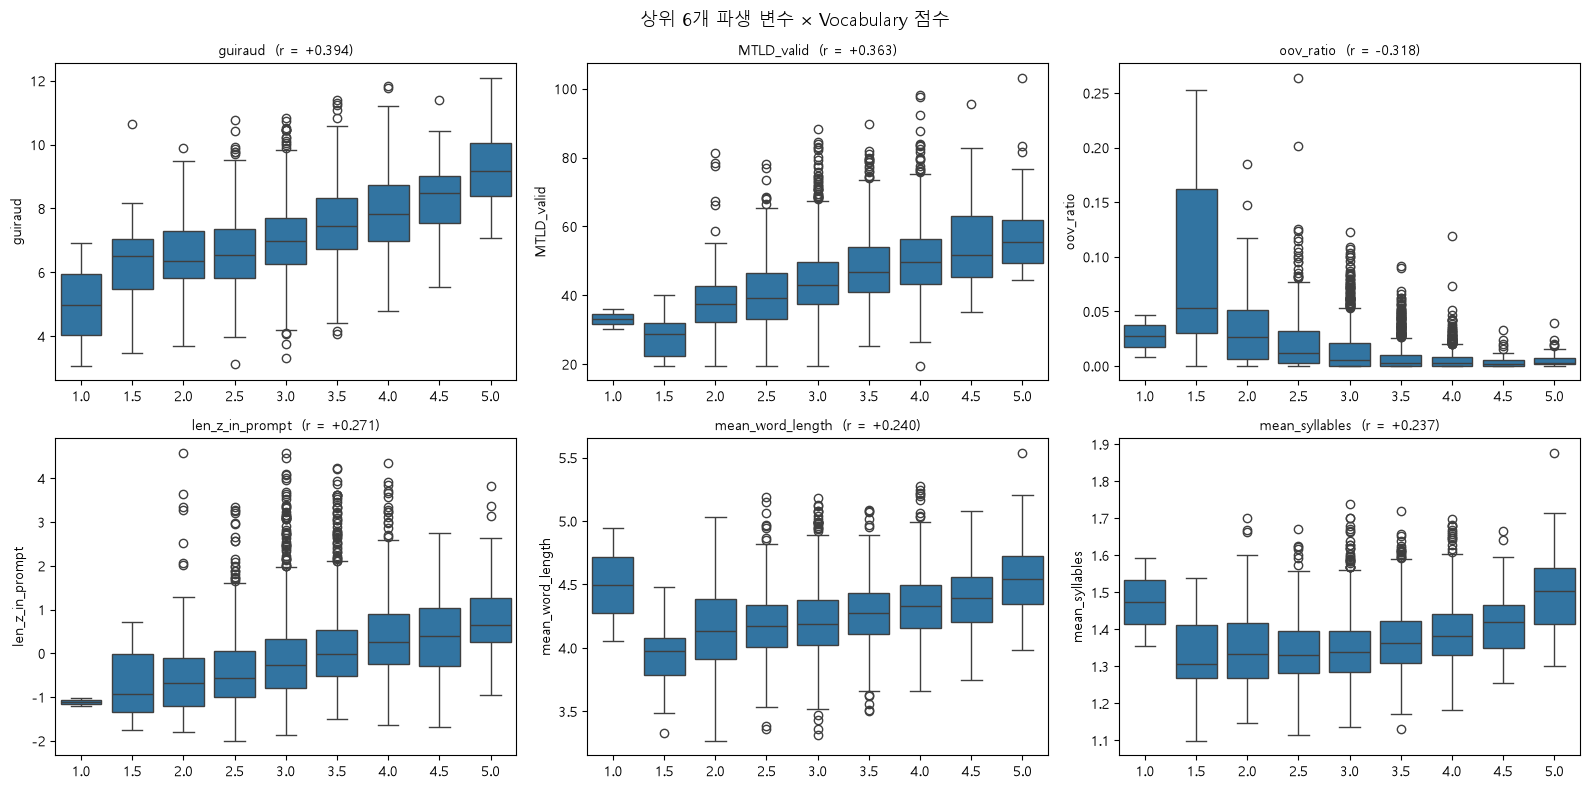

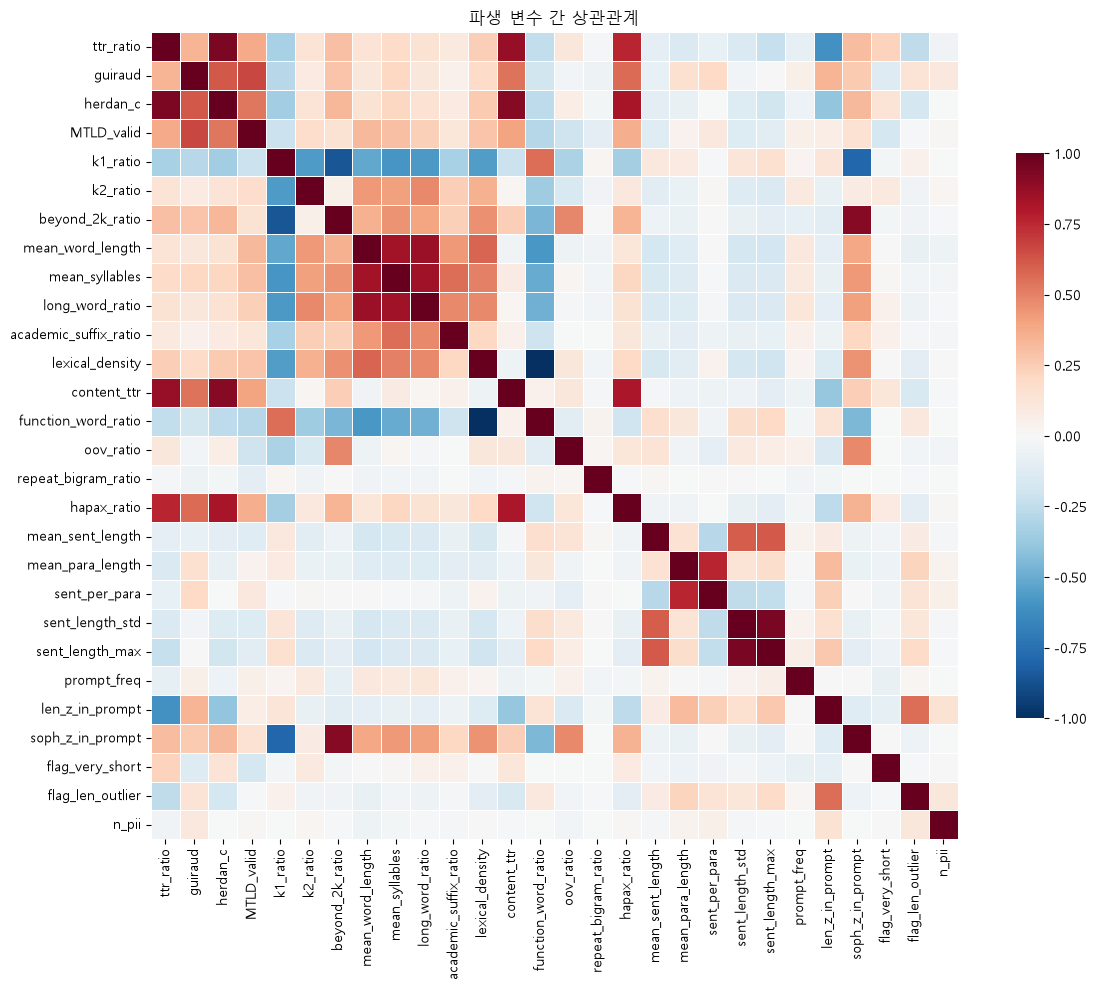

상관 0.85 이상 쌍 (STEP 6 제거 후보)
  lexical_density          ↔ function_word_ratio       r = 1.000
  sent_length_std          ↔ sent_length_max           r = 0.950
  ttr_ratio                ↔ herdan_c                  r = 0.943
  beyond_2k_ratio          ↔ soph_z_in_prompt          r = 0.913
  herdan_c                 ↔ content_ttr               r = 0.909
  ttr_ratio                ↔ content_ttr               r = 0.873
  mean_word_length         ↔ long_word_ratio           r = 0.865
  k1_ratio                 ↔ beyond_2k_ratio           r = 0.854


In [89]:
# ── [4-Z2] 시각적 검증 및 다중공선성 사전 점검 ──────────────
#
# 상관계수는 선형 관계만 포착합니다.
# 상관이 0에 가깝더라도 산점도가 U자형이면 비선형 관계가 존재하는 것이며,
# 이 경우 선형 회귀보다 트리 계열 모델이 적합합니다.
# 따라서 수치와 함께 분포를 확인하는 절차가 필요합니다.
#
# 두 번째 그림은 파생 변수 간 상관 구조입니다.
# 여기서 진하게 나타나는 쌍이 STEP 6의 제거 후보가 됩니다.

top6 = ranking.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), top6):
    sns.boxplot(x=df['Vocabulary'], y=df[col], ax=ax)
    ax.set_title(f'{col}  (r = {df[col].corr(df["Vocabulary"]):+.3f})', fontsize=10)
    ax.set_xlabel('')
fig.suptitle('상위 6개 파생 변수 × Vocabulary 점수', fontsize=13)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 10))
corr = df[all_derived].corr()
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=.4, ax=ax, cbar_kws={'shrink': .7})
# 진한 쌍은 STEP 6에서 한쪽만 유지
ax.set_title('파생 변수 간 상관관계', fontsize=12)
plt.tight_layout()
plt.show()

# 고상관 쌍을 자동 추출합니다.
# 다수 검출되는 것은 정상이며, 동일 구성 개념을 여러 방식으로 측정했기 때문입니다.
print('상관 0.85 이상 쌍 (STEP 6 제거 후보)')
hi = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = hi.stack().sort_values(ascending=False)
pairs = pairs[pairs > 0.85]
if len(pairs):
    for (a, b), v in pairs.items():
        print(f'  {a:24s} ↔ {b:24s}  r = {v:.3f}')
else:
    print('  없음')